# COS711 Assignment 1: MLP on Protein Tertiary Structure

Predict the **RMSD** (Å) of a candidate protein fold from physicochemical descriptors, then study
(1) how MLP design choices affect training, and (2) whether **learning-rate warmup** makes a network
more **robust to magnitude pruning**.

**Layout:** this notebook tells the story. The mechanics live in short modules under `src/`
(one concept per file). Written justifications are in `docs/`.

| Section | Contents |
|---|---|
| 1 | Data preparation: first look, splitting, feature relevance, outliers, scaling, imbalance |
| 2 | The MLP, training loop and baseline (incl. re-checking the feature and loss-weighting decisions) |
| 3 | Core investigation: optimisers, architecture, activation functions |
| 4 | Research investigation: warmup vs pruning robustness |

**How to run:** from the repo root, `python3 -m venv .venv && source .venv/bin/activate &&
pip install -r requirements.txt`, then open this notebook and *Restart & Run All*.

In [1]:
import sys
from pathlib import Path

# Make `src` importable whether the notebook is started from the repo root or from notebooks/
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import (FEATURES, INPUT_FEATURES, TARGET, RMSD_BIN_EDGES, RMSD_BIN_LABELS,
                      load_raw, clean, rmsd_bin, split_train_test, stratified_kfold)
from src.preprocessing import Preprocessor, LOG_FEATURES
from src.evaluation import regression_metrics, per_bin_metrics
from src import plotting
from src.plotting import BLUE, ORANGE, TEXT_PRIMARY, TEXT_SECONDARY

plotting.apply_style()
pd.set_option("display.precision", 3)

## 1. Data preparation

Every decision below is justified in more detail in `docs/01-data-preparation.md`.
**Rule:** once the test set is split off (1.2), every decision is made on the *training* set only.

### 1.1 First look

In [2]:
df_raw = load_raw()
print(f"raw shape: {df_raw.shape}")
print(f"missing values: {df_raw.isna().sum().sum()}")
print(f"exact duplicate rows: {df_raw.duplicated().sum()}")
print(f"rows sharing identical features but different RMSD: "
      f"{df_raw.drop_duplicates().duplicated(FEATURES, keep=False).sum()}")

df = clean(df_raw)  # drops exact duplicates (leakage risk across splits)
print(f"after removing duplicates: {df.shape}")

raw shape: (45730, 10)
missing values: 0
exact duplicate rows: 1711
rows sharing identical features but different RMSD: 83
after removing duplicates: (44019, 10)


In [3]:
summary = df.describe(percentiles=[0.01, 0.5, 0.99]).T
summary["skew"] = df.skew()
summary

,count,mean,std,min,1%,50%,99%,max,skew
F1,44019.0,9.875e+03,4054.023,2392.050,3946.457,8.903e+03,2.254e+04,4.003e+04,1.095
F2,44019.0,3.019e+03,1465.353,403.500,880.554,2.671e+03,7.477e+03,1.531e+04,1.193
F3,44019.0,3.025e-01,0.063,0.092,0.167,3.002e-01,4.605e-01,5.777e-01,0.240
F4,44019.0,1.035e+02,55.298,10.310,32.623,8.778e+01,2.883e+02,3.693e+02,1.222
F5,44019.0,1.369e+06,563505.024,319490.217,543853.811,1.238e+06,3.110e+06,5.472e+06,1.061
F6,44019.0,1.457e+02,69.870,31.970,48.752,1.262e+02,3.601e+02,5.984e+02,1.119
F7,44019.0,3.992e+03,2006.911,0.000,1403.275,3.841e+03,7.244e+03,1.059e+05,21.013
F8,44019.0,7.010e+01,56.490,0.000,4.000,5.400e+01,2.850e+02,3.500e+02,1.686
F9,44019.0,3.452e+01,5.979,15.228,19.682,3.530e+01,4.655e+01,5.530e+01,-0.473
RMSD,44019.0,7.796e+00,6.138,0.000,0.571,5.087e+00,2.043e+01,2.100e+01,0.553


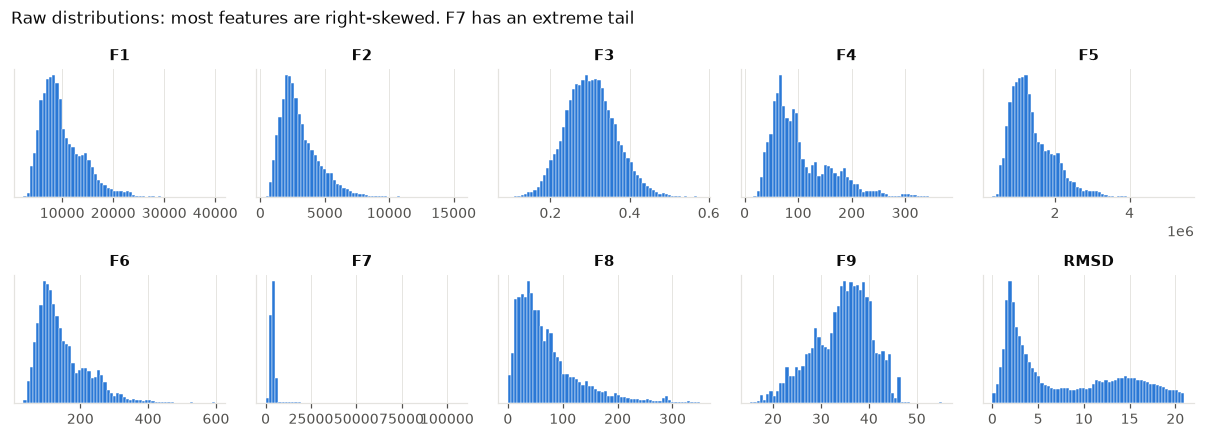

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(11, 4))
for ax, col in zip(axes.flat, FEATURES + [TARGET]):
    ax.hist(df[col], bins=60, color=BLUE, edgecolor="white", linewidth=0.3)
    ax.set_title(col)
    ax.set_yticks([])
fig.suptitle("Raw distributions: most features are right-skewed. F7 has an extreme tail", x=0.01, ha="left")
fig.tight_layout()
plotting.save(fig, "raw_distributions", "eda")
plt.show()

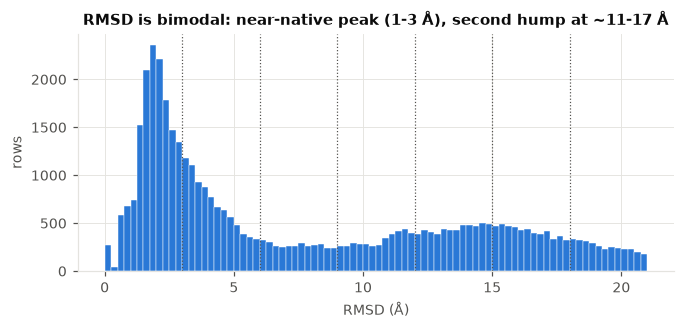

RMSD range: 0.00 to 21.00 Å, median 5.09 Å; rows with RMSD exactly 0: 272


In [5]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.hist(df[TARGET], bins=np.arange(0, 21.25, 0.25), color=BLUE, edgecolor="white", linewidth=0.3)
for edge in RMSD_BIN_EDGES[1:-1]:
    ax.axvline(edge, color=TEXT_SECONDARY, linewidth=0.8, linestyle=":")
ax.set_xlabel("RMSD (Å)")
ax.set_ylabel("rows")
ax.set_title("RMSD is bimodal: near-native peak (1-3 Å), second hump at ~11-17 Å")
plotting.save(fig, "rmsd_distribution", "eda")
plt.show()
print(f"RMSD range: {df[TARGET].min():.2f} to {df[TARGET].max():.2f} Å, median {df[TARGET].median():.2f} Å; "
      f"rows with RMSD exactly 0: {(df[TARGET] == 0).sum()}")

**Observations.** No missing values. All features are non-negative. F1, F2, F4, F5, F6 and F8
have skew > 1, and F7 (a Euclidean distance) has a very extreme right tail. F8 is integer-valued.
The target is bounded (0 to ~21 Å) and **bimodal**, not simply skewed. The dotted lines are the
3 Å bins used for stratification and per-bin evaluation.

### 1.2 Splitting

* **80 / 20 train/test hold-out, stratified on RMSD bin**, so the test set has the same target
  distribution (including the rarer 6-12 Å folds) as the training set. Fixed seed, so the test set
  is identical in every experiment and **locked** until final reporting.
* **5-fold stratified cross-validation on the training set** for every hyperparameter comparison
  (required by the spec). Inside each fold, a further 10 % of the fold's training part is held out
  for **early stopping**, so the stopping epoch is never chosen on the data we score.
* *Limitation:* the data has no protein IDs, so different decoys of the same protein can land in
  different splits. We cannot group by protein, so the scores may be slightly optimistic.

In [6]:
train_df, test_df = split_train_test(df)
print(f"train: {len(train_df)} rows | test: {len(test_df)} rows")

share = lambda d: pd.Series(np.bincount(rmsd_bin(d[TARGET]), minlength=7) / len(d), index=RMSD_BIN_LABELS)
(pd.DataFrame({"train %": share(train_df), "test %": share(test_df)}) * 100).round(2).T

train: 35215 rows | test: 8804 rows


,0-3,3-6,6-9,9-12,12-15,15-18,18-21
train %,34.34,18.80,7.48,8.87,12.14,11.34,7.03
test %,34.34,18.81,7.47,8.87,12.14,11.35,7.02


### 1.3 Feature relevance

Three complementary checks on the **training set**:
1. **Pearson / Spearman correlation** with RMSD: linear / monotonic relationships only.
2. **Mutual information (MI)**: any dependency, including non-linear. A column of pure random
   noise gives the "uninformative" reference value.
3. **Redundancy**: features that duplicate each other add no information.

In [7]:
from sklearn.feature_selection import mutual_info_regression

X_tr, y_tr = train_df[FEATURES], train_df[TARGET]
noise = pd.Series(np.random.default_rng(0).normal(size=len(X_tr)), name="NOISE (reference)")
X_with_noise = pd.concat([X_tr, noise], axis=1)

relevance = pd.DataFrame({
    "pearson": X_with_noise.corrwith(y_tr),
    "spearman": X_with_noise.corrwith(y_tr, method="spearman"),
    "mutual_info": mutual_info_regression(X_with_noise, y_tr, random_state=0),
})
relevance

,pearson,spearman,mutual_info
F1,-1.370e-02,-0.008,0.231
F2,1.587e-01,0.163,0.187
F3,3.750e-01,0.389,0.176
F4,-1.693e-01,-0.144,0.280
F5,-1.268e-02,-0.011,0.228
F6,-3.463e-02,-0.021,0.246
F7,-2.676e-03,-0.029,0.350
F8,-1.498e-04,0.073,0.243
F9,6.170e-02,0.061,0.297
NOISE (reference),1.292e-02,0.013,0.000


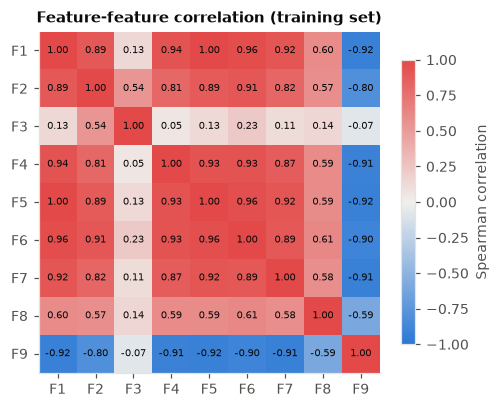

F5 / F1:        mean 138.5, coefficient of variation 0.026
F2 / (F1 × F3): mean 1.000, coefficient of variation 0.0000
MI(F5/F1 ratio, RMSD) = 0.089   vs noise 0.000


In [8]:
corr = X_tr.corr(method="spearman")
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(corr, cmap=plotting.DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES)), FEATURES)
ax.set_yticks(range(len(FEATURES)), FEATURES)
ax.grid(False)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6.5, color=TEXT_PRIMARY)
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman correlation")
ax.set_title("Feature-feature correlation (training set)")
plotting.save(fig, "feature_correlation", "eda")
plt.show()

# Two suspiciously strong relationships, checked directly:
ratio = X_tr["F5"] / X_tr["F1"]
print(f"F5 / F1:        mean {ratio.mean():.1f}, coefficient of variation {ratio.std() / ratio.mean():.3f}")
product = X_tr["F2"] / (X_tr["F1"] * X_tr["F3"])
print(f"F2 / (F1 × F3): mean {product.mean():.3f}, coefficient of variation {product.std() / product.mean():.4f}")

# F5 is not *exactly* proportional to F1. Does the small deviation (the ratio) carry information?
mi_ratio, mi_noise = mutual_info_regression(np.c_[ratio, noise], y_tr, random_state=0)
print(f"MI(F5/F1 ratio, RMSD) = {mi_ratio:.3f}   vs noise {mi_noise:.3f}")

**Model-based check.** Does removing a feature actually lose information? We fit a quick
gradient-boosted tree model (a strong non-linear model that needs no scaling, so it isolates the
*information content* of the features) with 5-fold CV on the training set, leaving out one feature
at a time.

In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor

def cv_r2(columns):
    scores = []
    for fit_idx, val_idx in stratified_kfold(y_tr, k=5):
        model = HistGradientBoostingRegressor(random_state=0)
        model.fit(X_tr.iloc[fit_idx][columns], y_tr.iloc[fit_idx])
        scores.append(model.score(X_tr.iloc[val_idx][columns], y_tr.iloc[val_idx]))
    return np.mean(scores), np.std(scores)

base_mean, base_std = cv_r2(FEATURES)
rows = [{"left out": "(none)", "cv_r2": base_mean, "std": base_std, "change": 0.0}]
for f in FEATURES:
    m, s = cv_r2([c for c in FEATURES if c != f])
    rows.append({"left out": f, "cv_r2": m, "std": s, "change": m - base_mean})
m, s = cv_r2([c for c in FEATURES if c not in ("F2", "F5")])
rows.append({"left out": "F2 and F5 together", "cv_r2": m, "std": s, "change": m - base_mean})
drop_one = pd.DataFrame(rows).set_index("left out")
drop_one

,cv_r2,std,change
left out,,,
(none),0.546,0.009,0.000
F1,0.541,0.011,-0.005
F2,0.547,0.008,0.001
F3,0.540,0.010,-0.006
F4,0.491,0.007,-0.055
F5,0.543,0.011,-0.003
F6,0.525,0.011,-0.021
F7,0.529,0.009,-0.017
F8,0.493,0.007,-0.053


**Decision: keep 8 features, drop F2 as *redundant*.**
* **No feature is uninformative.** Every feature's MI is far above the noise reference (≈ 0), even
  though several have almost zero Pearson correlation. The relationships are non-linear, so a
  correlation filter alone would wrongly discard useful features. (This is also why an MLP suits
  this problem better than a linear model.)
* **F2 is computable from other features:** F2 = F1 × F3 exactly. F3 is the *fraction* of the
  exposed area that is non-polar, so non-polar exposed area (F2) = total area (F1) × F3. Leaving
  F2 out costs nothing (the change is within noise).
* **F5 looks like a copy of F1 but isn't quite one.** F5 (molecular-mass-weighted exposed area)
  ≈ 138.5 × F1, correlation 1.00, and the tree model barely notices its removal. But the ratio F5/F1
  (≈ the average mass of the exposed residues, i.e. composition rather than size) varies by ~2.6 %,
  and that ratio has clearly non-zero MI with RMSD. **Section 2.3 settles it with the MLP itself:**
  the MLP is consistently better with F5, so **F5 is kept**. (After `log1p`, log F5 − log F1 is
  exactly the log of the ratio, a simple *difference* that an MLP's first layer computes easily.)
* F4 and F6 are also highly correlated with F1 (ρ > 0.9) but are **not** functions of it. Removing
  them costs clearly more R² (F4 the most of all), so they are kept.

### 1.4 Outliers

Counting "outliers" with textbook rules on raw, skewed data mostly flags the *normal* right tail.
So we compare the counts before and after a `log1p` transform of the skewed features.

In [10]:
def outlier_counts(X):
    q1, q3 = X.quantile(0.25), X.quantile(0.75)
    iqr = q3 - q1
    z = (X - X.mean()) / X.std()
    return pd.DataFrame({
        "IQR rule (1.5)": ((X < q1 - 1.5 * iqr) | (X > q3 + 1.5 * iqr)).sum(),
        "|z| > 4": (z.abs() > 4).sum(),
    })

X_log = X_tr[INPUT_FEATURES].copy()
logged = [f for f in LOG_FEATURES if f in INPUT_FEATURES]
X_log[logged] = np.log1p(X_log[logged])
pd.concat({"raw": outlier_counts(X_tr[INPUT_FEATURES]), "after log1p": outlier_counts(X_log)}, axis=1)

raw            after log1p        
   IQR rule (1.5) |z| > 4 IQR rule (1.5) |z| > 4
F1            885      39             29       0
F3            295       7            295       7
F4            924      52              9       3
F5            821      38             19       0
F6            978      25             14       0
F7            411     150           1053     121
F8           1864     156            573       4
F9             95       0             95       0

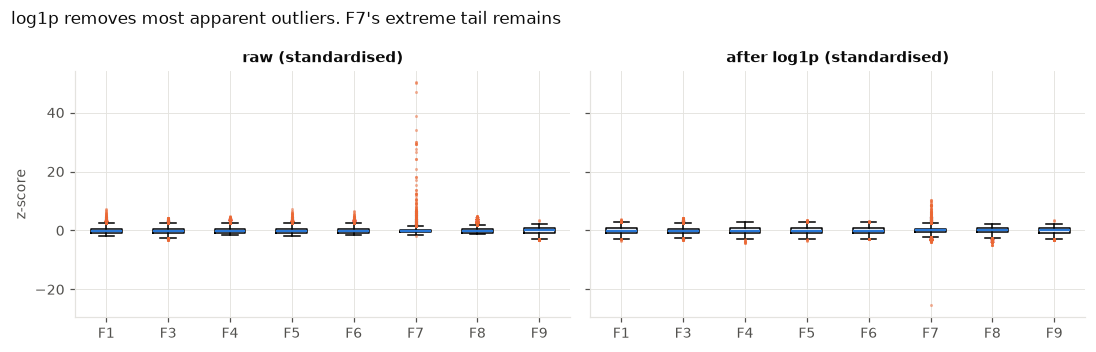

In [11]:
standardise = lambda X: (X - X.mean()) / X.std()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, X, title in [(axes[0], X_tr[INPUT_FEATURES], "raw (standardised)"),
                     (axes[1], X_log, "after log1p (standardised)")]:
    ax.boxplot(standardise(X).to_numpy(), tick_labels=INPUT_FEATURES, widths=0.5,
               flierprops=dict(marker=".", markersize=2, markeredgecolor=ORANGE, alpha=0.5),
               medianprops=dict(color=BLUE, linewidth=1.5))
    ax.set_title(title)
axes[0].set_ylabel("z-score")
fig.suptitle("log1p removes most apparent outliers. F7's extreme tail remains", x=0.01, ha="left")
fig.tight_layout()
plotting.save(fig, "outliers_before_after_log", "eda")
plt.show()

In [12]:
f7_extreme = X_tr["F7"] > X_tr["F7"].quantile(0.995)
print(f"F7 above its 99.5th percentile ({X_tr['F7'].quantile(0.995):.0f}): {f7_extreme.sum()} rows, "
      f"max {X_tr['F7'].max():.0f} vs median {X_tr['F7'].median():.0f}")
pd.DataFrame({
    "extreme-F7 rows": y_tr[f7_extreme].describe(),
    "all rows": y_tr.describe(),
}).T[["count", "mean", "25%", "50%", "75%"]]

F7 above its 99.5th percentile (11068): 177 rows, max 105948 vs median 3841


,count,mean,25%,50%,75%
extreme-F7 rows,177.0,8.657,3.174,5.951,13.857
all rows,35215.0,7.797,2.319,5.105,13.459


**Decision: transform and clip, don't delete.**
* Most "outliers" are the natural right tail of skewed, positive measurements (areas, masses).
  `log1p` makes them roughly symmetric, and the IQR flags for F1, F4, F6 and F8 drop sharply.
* **F7 is the exception.** Its raw maximum is ~28× its median, and even after the log it has extreme
  values (|z| > 4) at both ends. Its IQR count actually rises after the log, because the compressed
  bulk makes the low tail stand out. These rows look like
  measurement anomalies in F7 *only*: their other features and their RMSD values are ordinary and
  span the full range. Deleting them would throw away valid targets, and we could not delete such
  rows at prediction time anyway.
* So every feature is **clipped (winsorised) to its training-set 0.5th to 99.5th percentile** after
  the log. Rows are kept and extreme inputs can no longer dominate the weighted sums in the first
  layer.
* **The target is never treated as an outlier.** A large RMSD is a real bad fold, which is exactly
  what we are trying to predict.

### 1.5 Scaling

All features are continuous (F8 is an integer count but has 300+ distinct values), so they are
treated alike: `log1p` (skewed ones) → clip → **standardise** to mean 0, std 1. The target is
standardised for training and converted back to Å for every reported metric. All statistics come
from the training data (`Preprocessor.fit`).

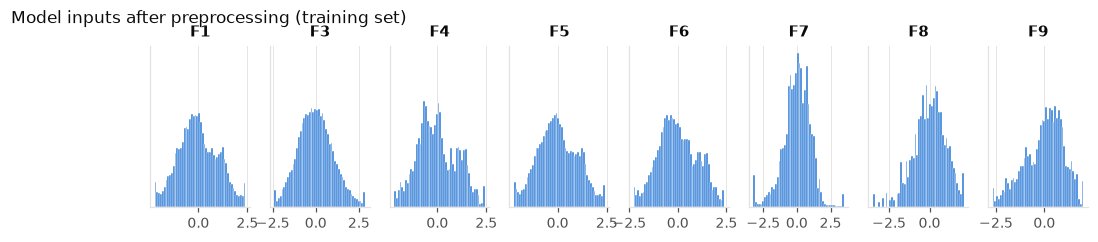

,F1,F3,F4,F5,F6,F7,F8,F9
mean,-6.500e-10,0.000,-1.300e-09,-1.300e-09,8.666e-10,0.000,2.167e-09,-6.500e-10
std,1.000e+00,1.000,1.000e+00,1.000e+00,1.000e+00,1.000,1.000e+00,1.000e+00
min,-2.227e+00,-2.399,-2.208e+00,-2.225e+00,-2.278e+00,-3.241,-3.489e+00,-2.668e+00
max,2.399e+00,2.863,2.425e+00,2.383e+00,2.389e+00,3.497,2.105e+00,2.016e+00


In [13]:
prep = Preprocessor().fit(train_df)
X_train = prep.transform_X(train_df)

fig, axes = plt.subplots(1, len(INPUT_FEATURES), figsize=(11, 1.9), sharey=True)
for i, (ax, col) in enumerate(zip(axes, INPUT_FEATURES)):
    ax.hist(X_train[:, i], bins=50, color=BLUE, edgecolor="white", linewidth=0.3)
    ax.set_title(col)
    ax.set_yticks([])
fig.suptitle("Model inputs after preprocessing (training set)", x=0.01, ha="left", y=1.05)
plotting.save(fig, "preprocessed_distributions", "eda")
plt.show()

pd.DataFrame({"mean": X_train.mean(axis=0), "std": X_train.std(axis=0),
              "min": X_train.min(axis=0), "max": X_train.max(axis=0)}, index=INPUT_FEATURES).T

**Why standardisation (and not min-max)?**
* Gradient descent works best when all inputs have a similar scale. Raw F5 is around 10⁶ while F3
  is around 0.3, so unscaled inputs would make the loss surface badly conditioned.
* Xavier/He initialisation assumes inputs with roughly unit variance.
* Sigmoid and tanh saturate (gradient ≈ 0) for large inputs. This matters for our activation axis.
* Min-max scaling would be distorted by F7's extreme values, squeezing the bulk of the data into a
  tiny interval. Log + clip + z-score avoids that.

### 1.6 Imbalance (skewed, bimodal target)

For regression, "imbalance" means some target ranges are much rarer than others.

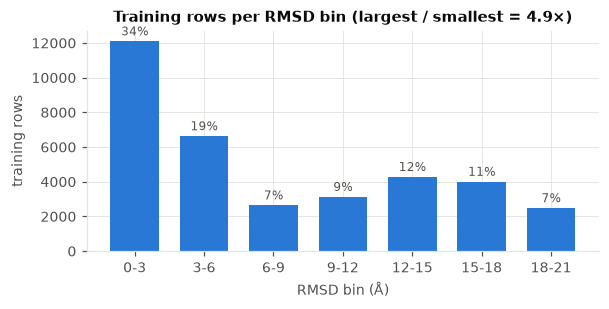

In [14]:
counts = pd.Series(np.bincount(rmsd_bin(y_tr), minlength=7), index=RMSD_BIN_LABELS)
fig, ax = plt.subplots(figsize=(6, 2.6))
bars = ax.bar(RMSD_BIN_LABELS, counts, color=BLUE, width=0.7)
ax.bar_label(bars, labels=[f"{c / counts.sum():.0%}" for c in counts], fontsize=8, color=TEXT_SECONDARY, padding=2)
ax.set_xlabel("RMSD bin (Å)")
ax.set_ylabel("training rows")
ax.set_title(f"Training rows per RMSD bin (largest / smallest = {counts.max() / counts.min():.1f}×)")
plotting.save(fig, "rmsd_bin_counts", "eda")
plt.show()

Why per-bin evaluation matters: a trivial model that always predicts the training mean, scored
on one CV fold (not the test set). Its overall RMSE looks like a single number, but its errors
are very different across bins.

In [15]:
fit_idx, val_idx = next(stratified_kfold(y_tr, k=5))
y_val = y_tr.iloc[val_idx].to_numpy()
y_pred_mean = np.full_like(y_val, y_tr.iloc[fit_idx].mean())

print("overall:", {k: round(v, 3) for k, v in regression_metrics(y_val, y_pred_mean).items()})
per_bin_metrics(y_val, y_pred_mean)

overall: {'rmse': 6.131, 'mae': 5.501, 'r2': -0.0}


,n,rmse,mae,bias
bin,,,,
0-3,2419,5.930,5.895,5.895
3-6,1324,3.694,3.596,3.596
6-9,526,0.907,0.765,0.294
9-12,625,2.981,2.855,-2.855
12-15,855,5.813,5.746,-5.746
15-18,799,8.672,8.630,-8.630
18-21,495,11.604,11.570,-11.570


**How imbalance is handled:**
* **Training:** stratified CV folds and early-stopping splits, so every fold sees the full RMSD
  range in the same proportions. We start with the plain (unweighted) MSE loss. In Phase 2 we
  compare it once against inverse-bin-frequency sample weights, and keep the weights only if they
  reduce the error in the rare bins without hurting the overall error much.
* **Testing:** the test set is stratified on the same bins.
* **Evaluation:** besides overall RMSE / MAE / R², we report **per-bin RMSE and bias**. Then good
  performance on the common 0-3 Å folds cannot hide poor performance on the rarer mid-range folds.
  The bias column shows *regression to the mean*: over-predicting low RMSD and under-predicting
  high RMSD.

### 1.7 Data preparation summary

| Step | Decision | Fitted on |
|---|---|---|
| Cleaning | Remove 1,711 exact duplicate rows → 44,019 rows | — |
| Splitting | 80/20 train/test, stratified on 3 Å RMSD bins, fixed seed. 5-fold stratified CV on train. 10 % of each fold's training part for early stopping | — |
| Feature relevance | Keep 8. Drop **F2** (= F1 × F3 exactly) as redundant. F5 kept: its ratio to F1 carries information (confirmed with the MLP, §2.3). No feature is uninformative (MI ≫ noise) | train |
| Outliers | `log1p` on skewed features, then clip to the 0.5th to 99.5th percentile. No rows deleted. Target untouched | train |
| Scaling | Standardise features (z-score). Standardise target for training, report in Å | train |
| Imbalance | Stratified splits, per-bin metrics. Loss weighting tested in Phase 2 | train |

## 2. The MLP, training loop and baseline

The mechanics, one file each (read them top to bottom; they are short):

| File | What it does |
|---|---|
| `src/model.py` | `MLP`: Linear → activation blocks, a linear output (regression), Xavier/He/random init |
| `src/schedules.py` | `learning_rate(step, ...)`: optional linear **warmup**, then constant or cosine |
| `src/training.py` | the explicit training loop: set LR → forward → MSE → backward → step; early stopping |
| `src/cv.py` | 5-fold CV: fit preprocessing on the fit rows, train, score the validation fold in Å |

Every configuration sees the **same folds**, so differences come from the configuration, not the split.

In [16]:
from dataclasses import replace
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor

from src.cv import cross_validate, cross_validate_sklearn
from src.schedules import learning_rate
from src.training import TrainConfig
from src.utils import use_single_cpu_thread
from src.plotting import AQUA, YELLOW

use_single_cpu_thread()   # tiny networks train ~3.6x faster on one thread (see src/utils.py)
N_JOBS = 5                # run the 5 CV folds in parallel processes
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

BASELINE = TrainConfig()  # 2x64 ReLU, He init, Adam lr=1e-3, batch 256, early stopping (patience 20)
BASELINE

TrainConfig(hidden_sizes=(64, 64), activation='relu', init='auto', optimizer='adam', lr=0.001, batch_size=256, max_epochs=500, warmup_epochs=0.0, decay='constant', patience=20, weighted_loss=False, seed=0)

### 2.1 Learning-rate schedules

The LR is a plain function of the step (`src/schedules.py`) and is set before every optimiser step.
Part 3 uses the warmup variants. Illustrated over 100 epochs with 5 epochs of warmup.

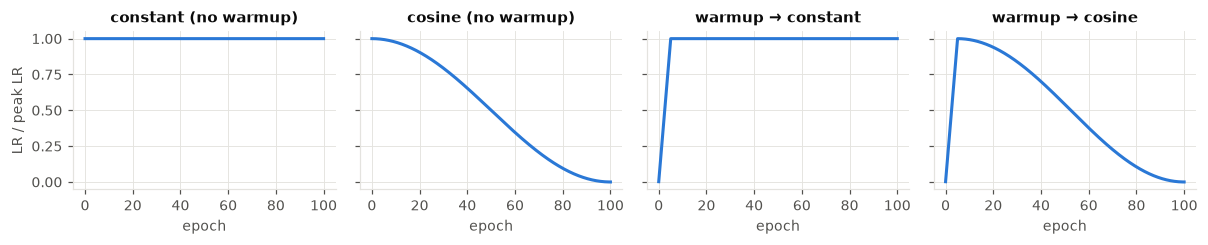

In [17]:
steps_per_epoch, epochs = 100, 100
total = steps_per_epoch * epochs
variants = [("constant (no warmup)", 0, "constant"), ("cosine (no warmup)", 0, "cosine"),
            ("warmup → constant", 5 * steps_per_epoch, "constant"), ("warmup → cosine", 5 * steps_per_epoch, "cosine")]

fig, axes = plt.subplots(1, 4, figsize=(11, 2.3), sharey=True)
for ax, (title, warmup, decay) in zip(axes, variants):
    lrs = [learning_rate(s, 1.0, total, warmup, decay) for s in range(total)]
    ax.plot(np.arange(total) / steps_per_epoch, lrs, color=BLUE)
    ax.set_title(title)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("LR / peak LR")
fig.tight_layout()
plotting.save(fig, "lr_schedules", "phase2")
plt.show()

### 2.2 Baseline: is the MLP learning anything useful?

**Hypothesis.** The MLP will clearly beat linear regression, because Phase 1 showed the
feature–RMSD relationships are mostly non-linear (high mutual information, near-zero Pearson r).
It should land close to a gradient-boosted tree model, a strong reference for tabular data.

To show the effect of the random seed, the MLP is cross-validated with 3 seeds (seed changes the
initial weights and mini-batch order, not the folds).

In [18]:
baselines = {
    "predict the mean": cross_validate_sklearn(DummyRegressor, train_df).summary(),
    "linear regression": cross_validate_sklearn(LinearRegression, train_df).summary(),
    "gradient boosting (reference)": cross_validate_sklearn(lambda: HistGradientBoostingRegressor(random_state=0), train_df).summary(),
}
mlp_runs = {seed: cross_validate(replace(BASELINE, seed=seed), train_df, n_jobs=N_JOBS) for seed in [0, 1, 2]}
for seed, res in mlp_runs.items():
    baselines[f"MLP 2x64 (seed {seed})"] = res.summary()

baseline_table = pd.DataFrame(baselines).T[["rmse_mean", "rmse_std", "mae_mean", "r2_mean", "r2_std", "best_epoch_mean"]]
baseline_table.to_csv(RESULTS / "phase2_baselines.csv")
baseline_table

,rmse_mean,rmse_std,mae_mean,r2_mean,r2_std,best_epoch_mean
predict the mean,6.136,0.005,5.515,-3.974e-06,3.718e-06,NaN
linear regression,5.185,0.045,4.247,2.860e-01,1.320e-02,NaN
gradient boosting (reference),4.134,0.044,3.123,5.462e-01,1.016e-02,NaN
MLP 2x64 (seed 0),4.094,0.046,3.027,5.548e-01,1.046e-02,149.4
MLP 2x64 (seed 1),4.095,0.029,3.012,5.547e-01,6.331e-03,140.8
MLP 2x64 (seed 2),4.080,0.046,3.002,5.578e-01,1.021e-02,171.8


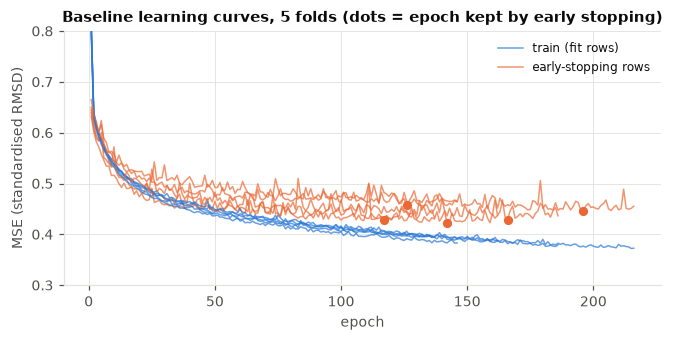

In [19]:
res = mlp_runs[0]
fig, ax = plt.subplots(figsize=(7, 3))
for fold, history in enumerate(res.histories):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], color=BLUE, linewidth=1, alpha=0.7, label="train (fit rows)" if fold == 0 else None)
    ax.plot(epochs, history["val_loss"], color=ORANGE, linewidth=1, alpha=0.7, label="early-stopping rows" if fold == 0 else None)
    best = res.folds.loc[fold, "best_epoch"]
    ax.plot(best, history["val_loss"][best - 1], "o", color=ORANGE, markersize=5)
ax.set_ylim(0.3, 0.8)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (standardised RMSD)")
ax.set_title("Baseline learning curves, 5 folds (dots = epoch kept by early stopping)")
ax.legend()
plotting.save(fig, "baseline_learning_curves", "phase2")
plt.show()

**Result: hypothesis supported.**
* The MLP reaches **RMSE ≈ 4.08–4.10 Å (R² ≈ 0.555)**, against 5.19 Å (R² 0.29) for linear regression and
  6.14 Å for predicting the mean. That's about 21 % lower error than linear regression, which confirms
  the relationships are non-linear. It is on par with (slightly better than) gradient boosting (4.13 Å).
* **Seed vs fold noise:** changing the seed moves the mean RMSE by only ~0.015 Å, while the
  fold-to-fold std is 0.03–0.05 Å. Differences smaller than this are not meaningful.
* **Learning curves:** the training loss keeps falling, but the early-stopping loss flattens after
  ~100 epochs and the gap widens. The network starts fitting details of its training rows that don't
  generalise (the onset of **overfitting**). Early stopping kept epochs 117–196. The early-stopping
  curve is jagged because the learning rate stays constant: with mini-batch noise the weights keep
  jittering around a minimum instead of settling. That is a motivation for LR decay, and is relevant
  to Section 4.
* **A tempting but wrong conclusion:** two very different models (MLP and boosted trees) both stop at
  R² ≈ 0.55, which *suggested* the 8 features set a ceiling. **Section 3.2 shows this was wrong:**
  larger MLPs reach R² ≈ 0.615. Both baselines were limited by capacity (and default settings), not by
  the features. Lesson: two models agreeing is weak evidence of a ceiling.

### 2.3 Re-checking the feature decision with the MLP

Phase 1 judged redundancy with a tree model. Here the MLP itself decides: the same baseline is
cross-validated with 7, 8 and 9 inputs, over **5 seeds**. Because every run uses the same folds,
we compare each feature set with the 7-feature set *seed by seed* (a paired comparison). That
removes most of the seed-to-seed noise from the difference.

In [20]:
feature_sets = {
    "7: drop F2 and F5": [c for c in FEATURES if c not in ("F2", "F5")],
    "8: drop F5 only": [c for c in FEATURES if c != "F5"],
    "8: drop F2 only (chosen)": INPUT_FEATURES,
    "9: all features": FEATURES,
}
feature_rmse = pd.DataFrame({
    name: [cross_validate(replace(BASELINE, seed=seed), train_df, features=cols, n_jobs=N_JOBS).summary()["rmse_mean"]
           for seed in range(5)]
    for name, cols in feature_sets.items()
})
feature_rmse.index.name = "seed"
feature_rmse.to_csv(RESULTS / "phase2_feature_sets.csv")

paired = feature_rmse.sub(feature_rmse.iloc[:, 0], axis=0)   # difference vs the 7-feature set, per seed
pd.DataFrame({
    "cv_rmse_mean": feature_rmse.mean(),
    "std_over_seeds": feature_rmse.std(),
    "diff_vs_7_mean": paired.mean(),
    "seeds_better_than_7": (paired < 0).sum(),
})

,cv_rmse_mean,std_over_seeds,diff_vs_7_mean,seeds_better_than_7
7: drop F2 and F5,4.153,0.022,0.000,0
8: drop F5 only,4.160,0.019,0.007,3
8: drop F2 only (chosen),4.097,0.012,-0.056,5
9: all features,4.115,0.010,-0.037,4


**Result: the Phase 1 decision was half right.**
* **Dropping F2 is confirmed.** Adding F2 back (9 features) changes RMSE by +0.018 Å, which is
  within the seed-to-seed noise. F2 = F1 × F3 adds nothing.
* **Dropping F5 was wrong.** Without F5 (the 7- and "drop F5 only" sets) RMSE is ~0.06 Å worse, and
  the chosen 8-feature set beats the 7-feature set in **all 5 seeds** (paired). The effect is small
  (≈ 1.4 %) but consistent. So **F5 is kept**.
* **Why the tree model missed it:** F5 ≈ 138.5 × F1, but the ~2.6 % deviation (the ratio F5/F1 ≈
  average mass of the exposed residues) carries information (MI 0.089 vs 0.000 for noise). After
  `log1p` that ratio is a simple *difference*, log F5 − log F1, which an MLP's first layer computes
  with two weights. A tree splits on one feature at a time and needs many splits to approximate a
  difference of two features.
* **Lesson:** "redundant" depends on the model. Check feature decisions with the model you will
  actually use.

### 2.4 Imbalance: does loss weighting help?

**Hypothesis.** Weighting each training row by the inverse frequency of its RMSD bin will reduce the
error in the rare bins, at the cost of a higher overall error (the model stops minimising plain MSE).

Compared with 3 seeds. Per-bin errors use the out-of-fold predictions (every training row predicted
by the fold in which it was a validation row).

In [21]:
weighted_runs = {seed: cross_validate(replace(BASELINE, seed=seed, weighted_loss=True), train_df, n_jobs=N_JOBS)
                 for seed in [0, 1, 2]}
pd.DataFrame({
    "unweighted": pd.concat([mlp_runs[s].summary() for s in [0, 1, 2]], axis=1).mean(axis=1),
    "inverse-bin weighted": pd.concat([weighted_runs[s].summary() for s in [0, 1, 2]], axis=1).mean(axis=1),
}).T[["rmse_mean", "mae_mean", "r2_mean", "best_epoch_mean"]]

,rmse_mean,mae_mean,r2_mean,best_epoch_mean
unweighted,4.090,3.014,0.556,154.0
inverse-bin weighted,4.307,3.373,0.507,97.2


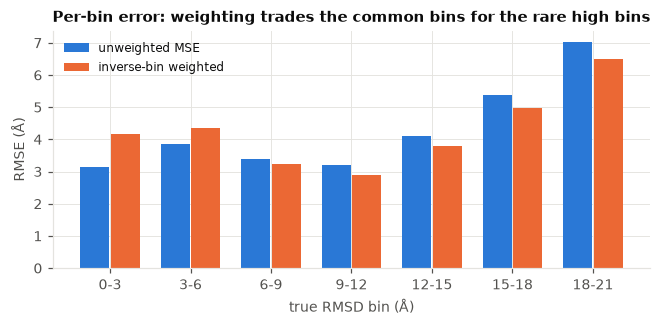

bin               0-3   3-6   6-9  9-12  12-15  15-18  18-21
unweighted rmse  3.14  3.85  3.39  3.21   4.10   5.39   7.02
           bias  1.90  2.21  1.31 -0.49  -2.34  -3.93  -5.62
weighted   rmse  4.16  4.36  3.24  2.91   3.80   4.97   6.48
           bias  2.85  2.81  1.43 -0.59  -2.40  -3.82  -5.38

In [22]:
def oof_per_bin(runs):
    """Per-bin RMSE and bias, averaged over seeds."""
    tables = [per_bin_metrics(r.predictions["y_true"], r.predictions["y_pred"]) for r in runs.values()]
    return pd.concat(tables).groupby(level=0, sort=False).mean()

bins_unweighted, bins_weighted = oof_per_bin(mlp_runs), oof_per_bin(weighted_runs)
per_bin_table = pd.concat({"unweighted": bins_unweighted[["rmse", "bias"]], "weighted": bins_weighted[["rmse", "bias"]]}, axis=1)
per_bin_table.to_csv(RESULTS / "phase2_loss_weighting_per_bin.csv")

x = np.arange(len(RMSD_BIN_LABELS))
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(x - 0.19, bins_unweighted["rmse"], width=0.36, color=BLUE, label="unweighted MSE")
ax.bar(x + 0.19, bins_weighted["rmse"], width=0.36, color=ORANGE, label="inverse-bin weighted")
ax.set_xticks(x, RMSD_BIN_LABELS)
ax.set_xlabel("true RMSD bin (Å)")
ax.set_ylabel("RMSE (Å)")
ax.set_title("Per-bin error: weighting trades the common bins for the rare high bins")
ax.legend()
plotting.save(fig, "loss_weighting_per_bin", "phase2")
plt.show()
per_bin_table.round(2).T

**Result: hypothesis partly supported. Decision: keep the unweighted MSE.**
* Weighting **does** lower the error in the five rarer bins (6–21 Å) by 0.15–0.54 Å, but it **raises**
  it in the two most common bins (0–3 Å: +1.02 Å, 3–6 Å: +0.51 Å), which hold 53 % of the rows.
  Overall RMSE gets worse (4.09 → 4.31 Å) and R² drops (0.556 → 0.507).
* **The bias is revealing.** Weighting barely changes the under-prediction of high RMSD (18–21 Å
  bias −5.6 → −5.4 Å). It mainly shifts *all* predictions upwards (0–3 Å bias +1.9 → +2.85 Å). So
  the high-bin errors are **not** mainly caused by the loss ignoring rare rows. The features don't
  separate high-RMSD decoys well, and the model hedges towards the middle (regression to the mean).
* Early stopping fires earlier with weights (97 vs 154 epochs): the model minimises a *weighted*
  loss while early stopping monitors the *unweighted* MSE, so the two disagree sooner.
* In practice (quality assessment) the near-native 0–3 Å decoys matter most, and weighting makes
  exactly those worse. The imbalance is therefore handled by stratified splits and per-bin reporting,
  not by loss weighting.

### 2.5 Baseline configuration (the reference for Section 3)

| Setting | Value | Why |
|---|---|---|
| Inputs | 8 features (F2 dropped) | §1.3 + §2.3 |
| Architecture | 2 hidden layers × 64 units, ReLU, He init | a common, modest starting point. Section 3 varies it |
| Optimiser | Adam, LR 1e-3, batch 256 | widely used defaults. Section 3 varies the optimiser |
| Loss | unweighted MSE on the standardised target | §2.4 |
| Stopping | early stopping on a 10 % split, patience 20, max 500 epochs | keeps the best epoch without overfitting |

## 3. Core investigation

Three axes, each changing **one** thing relative to the baseline (§2.5). The hypotheses were written
and committed **before** these experiments ran (`docs/02-core-investigation.md`, commit `90ef669`).

**Shared measurements** (every configuration × 3 seeds × 5 folds):
* **Final quality:** CV RMSE (Å) of the early-stopped model.
* **Convergence speed:** epochs until the early-stopping MSE first drops below **0.50**
  (standardised units: predict-the-mean = 1.0, baseline ends at ≈ 0.43).
* **Stability:** diverged folds, and the spread over folds and seeds.

A difference counts as real only if it exceeds the baseline noise (seed ~0.015 Å, fold std
0.03–0.05 Å) **and** points the same way in all 3 seeds (paired comparison).

Results are cached in `results/phase3_*.csv`. Set `RERUN = True` to retrain everything (~10 min on
12 cores).

In [23]:
from src.experiments import run_grid, aggregate, seeds_agree
from src.diagnostics import layer_gradient_sizes, SPEED_THRESHOLD
from src.model import MLP
from src.plotting import CATEGORICAL, TEXT_SECONDARY

RERUN = False

def plot_curves(ax, curves, labels, names=None, max_epoch=300):
    """Early-stopping MSE per epoch (averaged over folds and seeds), one line per configuration."""
    for colour, label in zip(CATEGORICAL, labels):
        c = curves[(curves["label"] == label) & (curves["epoch"] <= max_epoch)]
        ax.plot(c["epoch"], c["val_loss"], color=colour, linewidth=1.5, label=(names or {}).get(label, label))
    ax.axhline(SPEED_THRESHOLD, color=TEXT_SECONDARY, linewidth=0.8, linestyle=":")
    ax.set_xlabel("epoch")
    ax.set_ylabel("early-stopping MSE")

### 3.1 Axis A: Optimisers

SGD, SGD + momentum (β = 0.9), RMSprop and Adam, each on the **same LR grid** (1e-4 … 1e-1). One
shared grid is fairer than one fixed LR, because each optimiser has its own natural LR scale.

* **H-A1 (speed):** at their best LRs, Adam and RMSprop converge in the fewest epochs, plain SGD in the
  most, with momentum in between.
* **H-A2 (final quality):** at their best LRs, all four end within ~0.05 Å of each other.
* **H-A3 (sensitivity/stability):** Adam and RMSprop give near-best RMSE over a wider LR range than SGD.
  SGD + momentum diverges at a lower LR than plain SGD (effective step ≈ η / (1 − β) = 10η).

In [24]:
LRS = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
OPTIMISERS = ["sgd", "momentum", "rmsprop", "adam"]
opt_configs = {f"{opt} lr={lr:g}": replace(BASELINE, optimizer=opt, lr=lr) for opt in OPTIMISERS for lr in LRS}
opt_table, opt_curves = run_grid("optimisers", opt_configs, train_df, rerun=RERUN)

opt_summary = aggregate(opt_table, ["optimizer", "lr"])
opt_summary[["rmse", "rmse_seed_std", "epochs_to_0.50", "reached_0.50", "best_epoch", "diverged_folds"]].round(3)

rmse  rmse_seed_std  epochs_to_0.50 reached_0.50  \
optimizer lr                                                              
sgd       1.000e-04   4.928          0.032             NaN       0.0/15   
          3.000e-04   4.762          0.017             NaN       0.0/15   
          1.000e-03   4.525          0.024             NaN       0.0/15   
          3.000e-03   4.390          0.014         292.722       6.0/15   
          1.000e-02   4.469          0.054         112.000       3.0/15   
          3.000e-02   4.418          0.030          55.222       6.0/15   
          1.000e-01   4.438          0.037          44.500       3.0/15   
momentum  1.000e-04   4.522          0.023             NaN       0.0/15   
          3.000e-04   4.308          0.015         349.183      14.0/15   
          1.000e-03   4.210          0.019         118.133      15.0/15   
          3.000e-03   4.186          0.033          46.867      15.0/15   
          1.000e-02   4.078          0.035          20.267      15.0/15   
          3.000e-02   4.031          0.027          12.467      15.0/15   
          1.000e-01   5.778          0.489             NaN       0.0/15   
rmsprop   1.000e-04   4.251          0.005         159.067      15.0/15   
          3.000e-04   4.280          0.011          65.567      14.0/15   
          1.000e-03   4.311          0.031          32.556      11.0/15   
          3.000e-03   4.206          0.092          29.450      14.0/15   
          1.000e-02   4.349          0.076          36.700      10.0/15   
          3.000e-02   6.919          1.818             NaN       0.0/15   
          1.000e-01  55.126         20.293             NaN       0.0/15   
adam      1.000e-04   4.189          0.008         155.733      15.0/15   
          3.000e-04   4.143          0.004          55.733      15.0/15   
          1.000e-03   4.090          0.008          21.067      15.0/15   
          3.000e-03   4.039          0.021          12.400      15.0/15   
          1.000e-02   3.994          0.011           9.667      15.0/15   
          3.000e-02   4.206          0.016          18.400      15.0/15   
          1.000e-01   4.750          0.399             NaN       0.0/15   

                     best_epoch  diverged_folds  
optimizer lr                                     
sgd       1.000e-04     499.800             0.0  
          3.000e-04     499.200             0.0  
          1.000e-03     497.000             0.0  
          3.000e-03     322.400             0.0  
          1.000e-02      84.867             0.0  
          3.000e-02      50.600             0.0  
          1.000e-01      40.267             1.0  
momentum  1.000e-04     499.000             0.0  
          3.000e-04     490.400             0.0  
          1.000e-03     299.067             0.0  
          3.000e-03     144.600             0.0  
          1.000e-02     112.933             0.0  
          3.000e-02      92.333             0.0  
          1.000e-01      28.733             2.0  
rmsprop   1.000e-04     316.133             0.0  
          3.000e-04     105.733             0.0  
          1.000e-03      44.800             0.0  
          3.000e-03      54.533             0.0  
          1.000e-02      38.533             0.0  
          3.000e-02       4.200            11.0  
          1.000e-01       0.000            15.0  
adam      1.000e-04     481.600             0.0  
          3.000e-04     258.267             0.0  
          1.000e-03     154.000             0.0  
          3.000e-03      80.267             0.0  
          1.000e-02      77.867             0.0  
          3.000e-02      52.400             0.0  
          1.000e-01      36.267             0.0

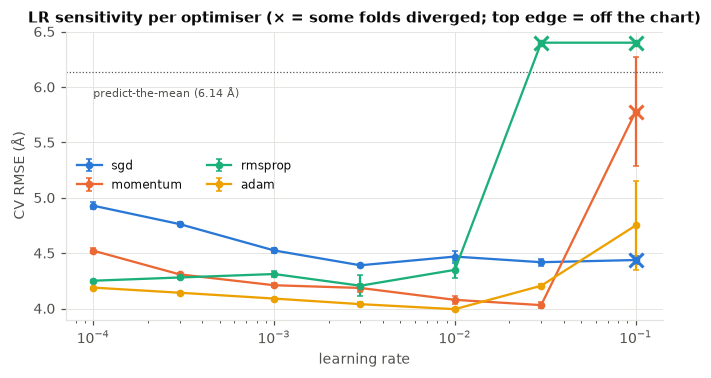

In [25]:
Y_TOP = 6.4   # values above this (fully diverged runs) are drawn at the top edge
fig, ax = plt.subplots(figsize=(7, 3.4))
for colour, opt in zip(CATEGORICAL, OPTIMISERS):
    s = opt_summary.loc[opt]
    shown = s["rmse"].clip(upper=Y_TOP)
    ax.errorbar(s.index, shown, yerr=s["rmse_seed_std"].where(s["rmse"] < Y_TOP, 0), color=colour, marker="o",
                markersize=4, linewidth=1.5, capsize=2, label=opt)
    diverged = s["diverged_folds"] > 0
    ax.plot(s.index[diverged], shown[diverged], "x", color=colour, markersize=9, markeredgewidth=2)
ax.set_ylim(3.9, Y_TOP + 0.1)
ax.axhline(6.136, color=TEXT_SECONDARY, linewidth=0.8, linestyle=":")
ax.text(1e-4, 6.0, "predict-the-mean (6.14 Å)", fontsize=7, color=TEXT_SECONDARY, va="top")
ax.set_xscale("log")
ax.set_xlabel("learning rate")
ax.set_ylabel("CV RMSE (Å)")
ax.set_title("LR sensitivity per optimiser (× = some folds diverged; top edge = off the chart)")
ax.legend(ncol=2, loc="center left")
plotting.save(fig, "optimisers_lr_sensitivity", "phase3")
plt.show()

In [26]:
best_lr = opt_summary["rmse"].groupby(level="optimizer", sort=False).idxmin()   # (optimizer, lr) of each best
best_rows = opt_summary.loc[best_lr.tolist()].copy()
# LR tolerance, two ways:
#   relative: grid LRs within 0.10 Å of THAT optimiser's own best (flatters optimisers whose best is poor)
#   absolute: grid LRs within 0.10 Å of the best RMSE of ANY optimiser (how many LRs give a good model)
overall_best = opt_summary["rmse"].min()
best_rows["lrs_near_own_best"] = [int((opt_summary.loc[o, "rmse"] <= opt_summary.loc[(o, lr), "rmse"] + 0.10).sum())
                                  for o, lr in best_lr]
best_rows["lrs_near_overall_best"] = [int((opt_summary.loc[o, "rmse"] <= overall_best + 0.10).sum()) for o, _ in best_lr]
best_rows[["rmse", "rmse_seed_std", "rmse_fold_std", "epochs_to_0.50", "reached_0.50", "best_epoch",
           "lrs_near_own_best", "lrs_near_overall_best"]].round(3)

,,rmse,rmse_seed_std,rmse_fold_std,epochs_to_0.50,reached_0.50,best_epoch,lrs_near_own_best,lrs_near_overall_best
optimizer,lr,,,,,,,,
sgd,0.003,4.390,0.014,0.057,292.722,6.0/15,322.400,4,0
momentum,0.030,4.031,0.027,0.040,12.467,15.0/15,92.333,2,2
rmsprop,0.003,4.206,0.092,0.082,29.450,14.0/15,54.533,3,0
adam,0.010,3.994,0.011,0.053,9.667,15.0/15,77.867,3,3


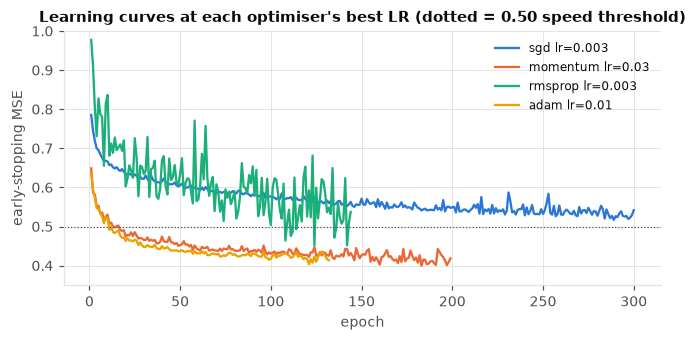

adam lr=0.01 vs sgd lr=0.003: mean diff -0.396 Å, adam lr=0.01 better in 3/3 seeds
adam lr=0.01 vs momentum lr=0.03: mean diff -0.037 Å, adam lr=0.01 better in 3/3 seeds
adam lr=0.01 vs rmsprop lr=0.003: mean diff -0.212 Å, adam lr=0.01 better in 3/3 seeds


In [27]:
best_labels = [f"{o} lr={lr:g}" for o, lr in best_lr]
fig, ax = plt.subplots(figsize=(7, 3))
plot_curves(ax, opt_curves, best_labels)
ax.set_ylim(0.35, 1.0)
ax.set_title("Learning curves at each optimiser's best LR (dotted = 0.50 speed threshold)")
ax.legend()
plotting.save(fig, "optimisers_learning_curves", "phase3")
plt.show()

for other in best_labels[:-1]:
    print(seeds_agree(opt_table, "label", best_labels[-1], other))   # Adam's best vs the others, per seed

**Verdicts.** (Each optimiser at its own best LR. Speed = epochs until early-stopping MSE < 0.50.)

| | Best LR | CV RMSE | Epochs to 0.50 |
|---|---|---|---|
| Adam | 1e-2 | **3.99 Å** | **9.7** |
| SGD + momentum | 3e-2 | 4.03 Å | 12.5 |
| RMSprop | 3e-3 | 4.21 Å | 29.5 |
| SGD | 3e-3 | 4.39 Å | 293 (only 6/15 folds ever got there) |

* **H-A1 (speed): partly supported.** Adam is fastest and plain SGD by far the slowest, as predicted.
  But **momentum beat RMSprop**: momentum alone gave a ~20× speed-up over plain SGD. The ordering
  "adaptive > momentum" was wrong. Adam's advantage seems to come largely from the momentum it
  contains.
* **H-A2 (final quality within 0.05 Å): contradicted.** The best results span 0.40 Å. Only Adam and
  momentum are close (3.99 vs 4.03 Å). Plain SGD at small LRs hit the 500-epoch limit *still
  improving* (best epoch ≈ 500), and at larger LRs early stopping ended it after 40–85 epochs at a
  worse RMSE. So under
  a fixed training budget and stopping rule, **speed turns into final quality**. A slow optimiser
  never gets to the finish line. (The H-A2 reasoning also assumed a feature ceiling, which §3.2
  disproves.)
* **H-A3 (LR tolerance): supported for Adam, contradicted for RMSprop. The momentum part is supported.**
  Adam gives a good model (within 0.10 Å of the overall best) at 3 grid LRs, momentum at 2, and SGD
  and RMSprop at none. RMSprop is the **least** tolerant: it diverges in 11/15 folds at 3e-2 and all
  folds at 1e-1. Momentum breaks at 1e-1 (RMSE 5.78 Å, 2 folds diverged), while plain SGD still
  trains there (4.44 Å). That is consistent with momentum's ~10× effective step.
* **Why RMSprop is fragile (verified separately):** PyTorch's RMSprop has **no bias correction**. Its
  running average of g² starts at 0, so its first update is **10× the LR** (still ~4× after 5 steps),
  whereas Adam's bias-corrected first update is 1× the LR. At LR 3e-2 every weight jumps by ~0.3 on
  step one. This "too-large steps at the very start" problem is exactly what **learning-rate warmup**
  addresses (Section 4).
* **Side effects of large LRs:** the fraction of dead ReLU units rises sharply with the LR (Adam: 0.3 %
  at 1e-3, 10 % at 1e-2, 32 % at 3e-2, 48 % at 1e-1). Big steps knock units into the never-active
  region. Noted for Section 4, because dead units are a form of "free" sparsity.
* Adam's best LR (1e-2) is 10× the baseline's 1e-3, and gives 3.99 Å vs 4.09 Å: the baseline LR was
  too cautious.

### 3.2 Axis B: Architecture (depth vs width)

Depth {1, 2, 3, 4} hidden layers × width {16, 64, 256}: 12 architectures from 161 to ~200k parameters.
Baseline otherwise (Adam 1e-3, ReLU + He, early stopping).

* **H-B1 (width):** 16 → 64 units clearly lowers RMSE. 64 → 256 helps much less (< 0.05 Å).
* **H-B2 (depth):** 1 hidden layer is worse than 2 at the same width. Beyond 2 layers, little further gain (< 0.05 Å).
* **H-B3 (overfitting vs early stopping):** larger nets overfit sooner (earlier best epoch, larger
  train–validation gap), but early stopping prevents them from ending up *worse* than medium nets.

In [28]:
DEPTHS, WIDTHS = [1, 2, 3, 4], [16, 64, 256]
arch_configs = {f"{d}x{w}": replace(BASELINE, hidden_sizes=(w,) * d) for d in DEPTHS for w in WIDTHS}
arch_table, arch_curves = run_grid("architecture", arch_configs, train_df, rerun=RERUN)

arch_summary = aggregate(arch_table, ["depth", "width"])
arch_summary["params"] = [MLP(len(INPUT_FEATURES), (w,) * d).count_parameters() for d, w in arch_summary.index]
arch_summary[["params", "rmse", "rmse_seed_std", "epochs_to_0.50", "best_epoch", "gap_at_best", "dead_fraction"]].round(3)

params   rmse  rmse_seed_std  epochs_to_0.50  best_epoch  \
depth width                                                             
1     16        161  4.626          0.030             NaN     310.267   
      64        641  4.390          0.008         167.000     258.733   
      256      2561  4.230          0.015          74.333     179.133   
2     16        433  4.424          0.015         262.250     246.733   
      64       4801  4.090          0.008          21.067     154.000   
      256     68353  3.951          0.011          12.533      93.200   
3     16        705  4.331          0.020         119.083     227.733   
      64       8961  3.998          0.010          13.200     103.533   
      256    134145  3.831          0.019           7.133      65.200   
4     16        977  4.301          0.025          99.067     189.600   
      64      13121  3.965          0.016           8.600      66.133   
      256    199937  3.805          0.019           5.000      54.200   

             gap_at_best  dead_fraction  
depth width                              
1     16          -0.002          0.000  
      64           0.007          0.000  
      256          0.016          0.000  
2     16           0.006          0.004  
      64           0.044          0.003  
      256          0.083          0.022  
3     16           0.015          0.000  
      64           0.070          0.006  
      256          0.152          0.014  
4     16           0.020          0.015  
      64           0.085          0.004  
      256          0.188          0.009

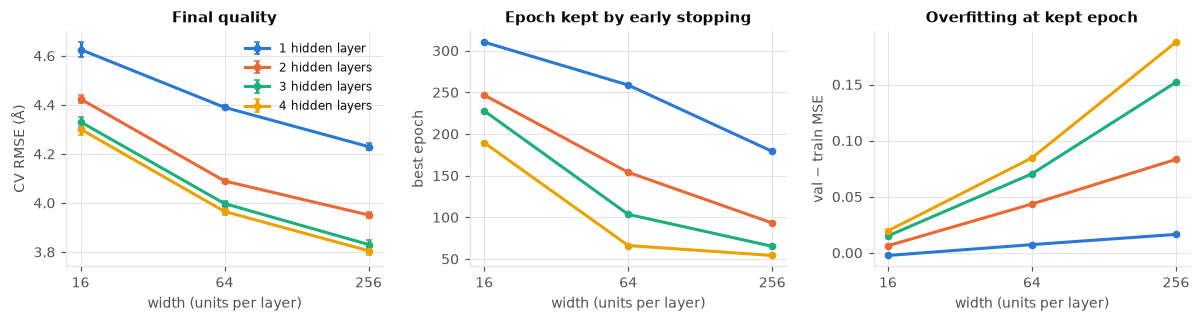

2x64 vs 2x16: mean diff -0.334 Å, 2x64 better in 3/3 seeds
2x256 vs 2x64: mean diff -0.139 Å, 2x256 better in 3/3 seeds
2x64 vs 1x64: mean diff -0.300 Å, 2x64 better in 3/3 seeds
4x64 vs 2x64: mean diff -0.124 Å, 4x64 better in 3/3 seeds
4x256 vs 2x64: mean diff -0.285 Å, 4x256 better in 3/3 seeds


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for colour, d in zip(CATEGORICAL, DEPTHS):
    s = arch_summary.loc[d]
    label = f"{d} hidden layer{'s' if d > 1 else ''}"
    axes[0].errorbar(WIDTHS, s["rmse"], yerr=s["rmse_seed_std"], color=colour, marker="o", markersize=4, capsize=2, label=label)
    axes[1].plot(WIDTHS, s["best_epoch"], color=colour, marker="o", markersize=4)
    axes[2].plot(WIDTHS, s["gap_at_best"], color=colour, marker="o", markersize=4)
for ax, title, ylabel in zip(axes, ["Final quality", "Epoch kept by early stopping", "Overfitting at kept epoch"],
                             ["CV RMSE (Å)", "best epoch", "val − train MSE"]):
    ax.set_xscale("log", base=2)
    ax.set_xticks(WIDTHS, [str(w) for w in WIDTHS])
    ax.set_xlabel("width (units per layer)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
axes[0].legend()
fig.tight_layout()
plotting.save(fig, "architecture", "phase3")
plt.show()

print(seeds_agree(arch_table, "label", "2x64", "2x16"))     # H-B1: 16 -> 64
print(seeds_agree(arch_table, "label", "2x256", "2x64"))    # H-B1: 64 -> 256
print(seeds_agree(arch_table, "label", "2x64", "1x64"))     # H-B2: 1 -> 2 layers
print(seeds_agree(arch_table, "label", "4x64", "2x64"))     # H-B2: 2 -> 4 layers
print(seeds_agree(arch_table, "label", "4x256", "2x64"))    # H-B3: largest vs baseline

**Verdicts.** Every step up in width or depth lowered the RMSE, in 3/3 seeds. The largest net
(4 × 256, ~200k parameters) is best: **3.81 Å, R² 0.615**, vs 4.09 Å for the 2 × 64 baseline.

* **H-B1 (width, diminishing returns): partly supported.** 16 → 64 units: −0.33 Å. 64 → 256: −0.14 Å
  (depth 2). The returns *do* diminish, but the second gain is ~3× larger than the 0.05 Å we predicted.
* **H-B2 (depth): first half supported, second half contradicted.** 1 → 2 layers: −0.30 Å (width 64),
  as predicted. But 2 → 3 (−0.09 Å) and 2 → 4 (−0.12 Å) also help, beyond the 0.05 Å threshold.
* **H-B3 (overfitting vs early stopping): supported.** Bigger nets overfit sooner and harder: the kept
  epoch falls from ~310 (1 × 16) to ~54 (4 × 256), and the train–validation gap at that epoch grows
  from ≈ 0 to 0.19. Yet early stopping keeps them from ending worse. The largest net is the best.
* **Depth is more parameter-efficient than width here:** 4 × 64 (≈ 13k parameters) matches 2 × 256
  (≈ 68k parameters) to within 0.014 Å.
* **Bigger nets also train faster per epoch of progress:** 4 × 256 reaches MSE < 0.50 in 5 epochs vs 21
  for 2 × 64. Over-parameterised networks have an easier loss landscape to descend.
* **What went wrong in our reasoning:** H-B1/H-B2 assumed the feature "ceiling" from Phase 2. That
  ceiling was the *baseline's capacity*. Our hypotheses were too pessimistic about capacity, which is
  itself a useful finding.

### 3.3 Axis C: Activation functions

Sigmoid, tanh, ReLU, Leaky ReLU (slope 0.01), each with its matching initialisation (Xavier for
sigmoid/tanh, He for the ReLU family), at the baseline depth (2 × 64) and a deeper net (4 × 64).

* **H-C1 (speed):** the ReLU family converges fastest, tanh next, sigmoid slowest.
* **H-C2 (vanishing gradients):** sigmoid's gradient ratio (first ÷ last layer) is far smaller than the
  others' and shrinks from 2 to 4 layers. Its RMSE gap to the others is larger at depth 4. Expected
  moderation: Adam partly compensates, so the effect should be clearer in the gradients than in RMSE.
* **H-C3 (ReLU vs Leaky ReLU):** tanh, ReLU and Leaky ReLU end within ~0.05 Å of each other. Leaky
  ReLU gains nothing, because few ReLU units die (< 10 %).

In [30]:
ACTIVATIONS = ["sigmoid", "tanh", "relu", "leaky_relu"]
act_configs = {f"{a} {d}x64": replace(BASELINE, activation=a, hidden_sizes=(64,) * d) for d in [2, 4] for a in ACTIVATIONS}
act_table, act_curves = run_grid("activations", act_configs, train_df, rerun=RERUN)

act_summary = aggregate(act_table, ["depth", "activation"])
act_summary[["rmse", "rmse_seed_std", "epochs_to_0.50", "reached_0.50", "best_epoch", "dead_fraction"]].round(3)

rmse  rmse_seed_std  epochs_to_0.50 reached_0.50  \
depth activation                                                      
2     sigmoid     4.344          0.018         423.317      11.0/15   
      tanh        4.063          0.041          64.133      15.0/15   
      relu        4.090          0.008          21.067      15.0/15   
      leaky_relu  4.095          0.017          21.200      15.0/15   
4     sigmoid     4.264          0.036         339.667      15.0/15   
      tanh        3.897          0.019          21.067      15.0/15   
      relu        3.965          0.016           8.600      15.0/15   
      leaky_relu  3.958          0.025           8.467      15.0/15   

                  best_epoch  dead_fraction  
depth activation                             
2     sigmoid        495.867            NaN  
      tanh           259.800            NaN  
      relu           154.000          0.003  
      leaky_relu     145.000          0.002  
4     sigmoid        481.067            NaN  
      tanh           120.933            NaN  
      relu            66.133          0.004  
      leaky_relu      85.467          0.000

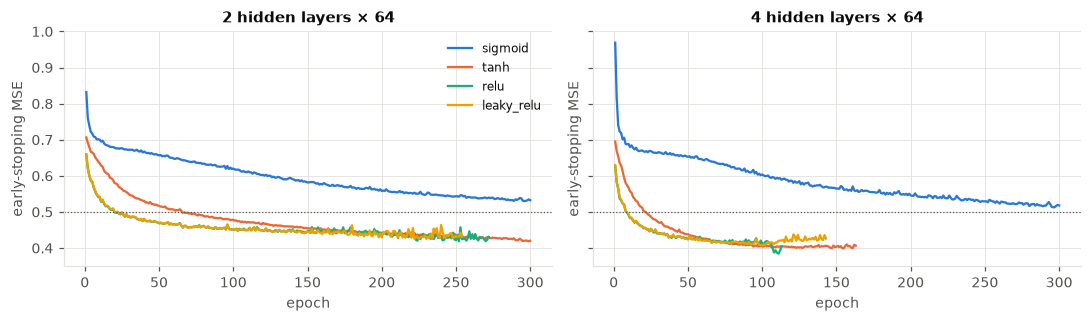

relu 2x64 vs sigmoid 2x64: mean diff -0.254 Å, relu 2x64 better in 3/3 seeds
relu 2x64 vs tanh 2x64: mean diff +0.027 Å, relu 2x64 better in 1/3 seeds
leaky_relu 2x64 vs relu 2x64: mean diff +0.005 Å, leaky_relu 2x64 better in 1/3 seeds
relu 4x64 vs sigmoid 4x64: mean diff -0.298 Å, relu 4x64 better in 3/3 seeds
relu 4x64 vs tanh 4x64: mean diff +0.068 Å, relu 4x64 better in 0/3 seeds
leaky_relu 4x64 vs relu 4x64: mean diff -0.008 Å, leaky_relu 4x64 better in 2/3 seeds


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, d in zip(axes, [2, 4]):
    plot_curves(ax, act_curves, [f"{a} {d}x64" for a in ACTIVATIONS], names={f"{a} {d}x64": a for a in ACTIVATIONS})
    ax.set_title(f"{d} hidden layers × 64")
    ax.set_ylim(0.35, 1.0)
axes[0].legend()
fig.tight_layout()
plotting.save(fig, "activations_learning_curves", "phase3")
plt.show()

for d in [2, 4]:
    print(seeds_agree(act_table, "label", f"relu {d}x64", f"sigmoid {d}x64"))
    print(seeds_agree(act_table, "label", f"relu {d}x64", f"tanh {d}x64"))
    print(seeds_agree(act_table, "label", f"leaky_relu {d}x64", f"relu {d}x64"))

**Gradient-flow diagnostic (H-C2).** At initialisation, on one batch of 1,024 training rows: the
average |gradient| of each layer's weights, averaged over 10 random initialisations. Depth 8 is
included as an extra illustration of the trend.

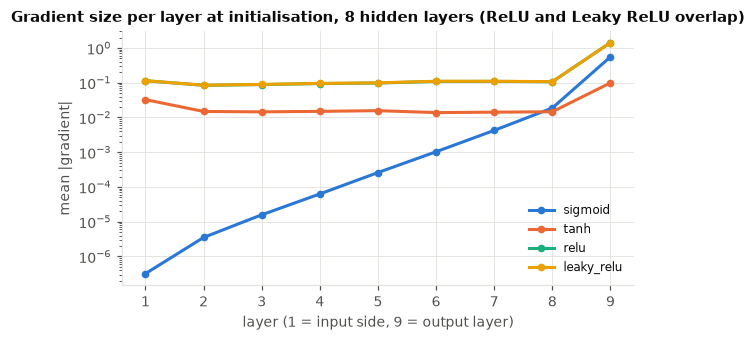

,depth 2: first ÷ last layer,depth 4: first ÷ last layer,depth 8: first ÷ last layer
sigmoid,0.003,2.000e-04,0.000
tanh,0.308,2.702e-01,0.329
relu,0.095,9.110e-02,0.080
leaky_relu,0.096,9.160e-02,0.081


In [32]:
import torch

prep_all = Preprocessor().fit(train_df)
batch = train_df.sample(1024, random_state=0)
X_batch, y_batch = prep_all.transform_X(batch), prep_all.transform_y(batch)

def gradient_profile(activation, depth, n_seeds=10):
    profiles = []
    for seed in range(n_seeds):
        torch.manual_seed(seed)
        profiles.append(layer_gradient_sizes(MLP(len(INPUT_FEATURES), (64,) * depth, activation), X_batch, y_batch))
    return np.mean(profiles, axis=0)

ratios = pd.DataFrame({d: {a: (lambda p: p[0] / p[-1])(gradient_profile(a, d)) for a in ACTIVATIONS} for d in [2, 4, 8]})
ratios.columns = [f"depth {d}: first ÷ last layer" for d in [2, 4, 8]]

fig, ax = plt.subplots(figsize=(6, 3))
for colour, a in zip(CATEGORICAL, ACTIVATIONS):
    profile = gradient_profile(a, 8)
    ax.plot(range(1, len(profile) + 1), profile, color=colour, marker="o", markersize=4, label=a)
ax.set_yscale("log")
ax.set_xlabel("layer (1 = input side, 9 = output layer)")
ax.set_ylabel("mean |gradient|")
ax.set_title("Gradient size per layer at initialisation, 8 hidden layers (ReLU and Leaky ReLU overlap)")
ax.legend()
plotting.save(fig, "activations_gradient_flow", "phase3")
plt.show()
ratios.round(4)

**Verdicts.**

* **H-C1 (speed: ReLU family > tanh > sigmoid): supported.** Epochs to MSE < 0.50: ReLU/Leaky ReLU
  21 and 8.6, tanh 64 and 21, sigmoid 423 and 340 (depth 2 and 4). At depth 2 sigmoid never got
  there in 4 of 15 folds.
* **H-C2 (vanishing gradients): supported, and moderated by Adam as predicted.** The gradient
  diagnostic is textbook: with sigmoid, the gradient shrinks by ≈ **4× per layer** going backwards
  (8 hidden layers: from 0.56 at the output layer to 3 × 10⁻⁷ at the first, a factor of a million).
  That matches sigmoid's maximum derivative of 0.25. The first ÷ last ratio collapses with depth
  (2.7e-3 → 1.7e-4 → 5.8e-7 for depth 2 → 4 → 8), while tanh (~0.3) and ReLU (~0.09) stay **flat**
  across depths: their hidden layers all get similar gradients. In RMSE the sigmoid gap to ReLU grows
  only slightly (0.25 → 0.30 Å), and sigmoid *itself* improves from depth 2 to 4. Adam divides each
  weight's step by its own gradient scale, so even tiny gradients produce normal-sized updates. The
  vanishing shows up in *speed*, not final quality.
* **H-C3 (tanh ≈ ReLU ≈ Leaky ReLU, Leaky gains nothing): partly supported.** Leaky ReLU vs ReLU: no
  difference (+0.005 and −0.008 Å, mixed across seeds), and dead ReLU units are below 0.5 %, far under
  10 %. So the "Leaky gains nothing because nothing dies" part holds. But **tanh beat ReLU at depth 4**
  (3.90 vs 3.97 Å, all 3 seeds), beyond our 0.05 Å threshold. tanh trains ~2.5× slower but ends
  better. One plausible reason (not tested): tanh is smooth, while ReLU nets build piecewise-linear
  functions, and RMSD is presumably a smooth function of the features.
* (ReLU and Leaky ReLU overlap almost exactly in the gradient plot.)

### 3.4 Base configuration for Section 4 (warmup vs pruning)

| Choice | Value | Evidence |
|---|---|---|
| Architecture | **4 × 256** (~200k weights) | best RMSE (§3.2), and lots of redundant capacity, which pruning needs. Still only ~10 s per fold |
| Activation / init | **ReLU, He** | fastest to train. The standard in the pruning/lottery-ticket papers we are reproducing. tanh's small edge (§3.3) is not worth a slower, less comparable setup |
| Optimiser | **SGD + momentum (0.9)** | it has a **sharp LR-tolerance boundary** (fine at 3e-2, breaks at 1e-1, §3.1), which is exactly what the warmup hypothesis is about. It's also the optimiser used by Frankle & Carbin and Renda et al. Adam degrades gradually instead of breaking, and corrects its own early steps (bias correction), which would blur the effect |

The LR boundary was measured on 2 × 64. Section 4 re-measures it on 4 × 256, with and without warmup
(that sweep *is* the first part of the research question).

## 4. Research investigation: does warmup make the network robust to pruning?

**The hypothesised chain (spec §2.3):** warmup → a larger LR becomes trainable → training at a larger
LR yields a network that recovers better from pruning. So warmup would help *indirectly*.

Design, hypotheses and decision rules were committed **before** running (`docs/03-warmup-pruning.md`,
commit `243937b`). Code: `src/warmup_pruning.py`, `src/pruning.py`.

| Fixed setup | |
|---|---|
| Network | 4 × 256, ReLU, He init (~200k weights) |
| Optimiser | SGD + momentum 0.9, batch 256, **100 epochs, no early stopping**, cosine decay to 0 |
| Warmup | linear, first **5 epochs**, then the same cosine decay |
| Data | fit 90 % / validation 10 % of the training set (all *choices*). **Test set for every reported pruning result** |
| Pruning | one-shot **global magnitude** pruning of all weight matrices (biases kept) |
| Fine-tuning | identical for all: SGD + momentum, **LR 0.001, 10 epochs**, pruned weights held at 0 |
| Seeds | 3 for the LR sweep, **5** for the conditions |

In [33]:
from src.warmup_pruning import (prepare_data, lr_sweep, summarise_sweep, max_stable_lr, choose_conditions,
                                prune_and_finetune, paired_check, schedule, SPARSITIES)
from src.pruning import global_magnitude_masks
from src.training import train
from src.plotting import GREEN, VIOLET

wp_data = prepare_data(train_df, test_df)   # test_df is used here for the first time
COND_COLOURS = {"A": BLUE, "B": ORANGE, "C": AQUA}

### 4.1 Step 1: does warmup raise the tolerable learning rate? (H1)

**H1:** the max stable LR with warmup is at least one grid step higher than without.
*Max stable LR* = the largest LR where all 3 seeds train without diverging **and** the validation RMSE
is within 0.10 Å of that schedule's best.

In [34]:
sweep = lr_sweep(wp_data, rerun=RERUN)
sweep_summary = summarise_sweep(sweep)
table = sweep_summary.reset_index().pivot(index="lr", columns="warmup", values=["val_rmse", "diverged_seeds"])
table.columns = [f"{'warmup' if w else 'no warmup'}: {m}" for m, w in table.columns]
table.round(3)

,no warmup: val_rmse,warmup: val_rmse,no warmup: diverged_seeds,warmup: diverged_seeds
lr,,,,
0.005,3.732,3.680,0.0,0.0
0.010,3.804,3.625,2.0,0.0
0.020,NaN,3.631,3.0,0.0
0.030,NaN,3.656,3.0,0.0
0.050,NaN,3.714,3.0,0.0
0.100,NaN,3.710,3.0,0.0
0.200,NaN,3.730,3.0,0.0


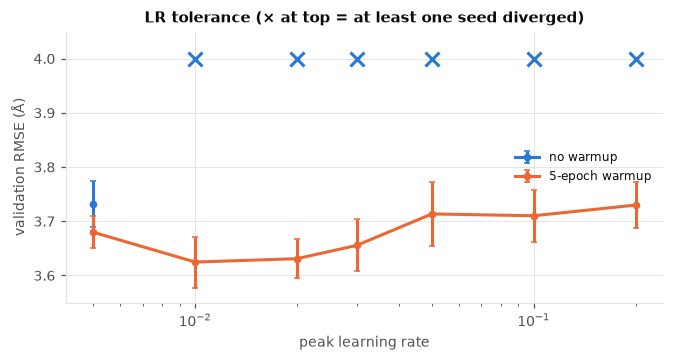

max stable LR  -  no warmup: 0.005 | warmup: 0.1
first-epoch divergences without warmup: 17 of 17 diverged runs


,warmup,peak LR
"A: no warmup, η0",False,0.005
"B: warmup, η1 > η0",True,0.2
"C: warmup, η0 (control)",True,0.005


In [35]:
Y_TOP = 4.0
fig, ax = plt.subplots(figsize=(7, 3.2))
for warmup, colour, name in [(False, BLUE, "no warmup"), (True, ORANGE, "5-epoch warmup")]:
    s = sweep_summary.loc[warmup]
    ok = s["diverged_seeds"] == 0
    ax.errorbar(s.index[ok], s["val_rmse"][ok], yerr=s["val_rmse_std"][ok].fillna(0), color=colour, marker="o",
                markersize=4, capsize=2, label=name)
    bad = s.index[s["diverged_seeds"] > 0]
    ax.plot(bad, [Y_TOP] * len(bad), "x", color=colour, markersize=9, markeredgewidth=2)
ax.set_xscale("log")
ax.set_ylim(3.55, Y_TOP + 0.05)
ax.set_xlabel("peak learning rate")
ax.set_ylabel("validation RMSE (Å)")
ax.set_title("LR tolerance (× at top = at least one seed diverged)")
ax.legend(loc="center right")
plotting.save(fig, "lr_tolerance", "phase4")
plt.show()

print("max stable LR  -  no warmup:", max_stable_lr(sweep_summary, False), "| warmup:", max_stable_lr(sweep_summary, True))
print("first-epoch divergences without warmup:", int((sweep[~sweep.warmup & sweep.diverged].diverged_at_epoch == 1).sum()),
      "of", int(sweep[~sweep.warmup].diverged.sum()), "diverged runs")

conditions = choose_conditions(sweep_summary)   # the pre-registered rules (src/warmup_pruning.py)
A, B, C = list(conditions)
pd.DataFrame(conditions, index=["warmup", "peak LR"]).T

**H1: strongly supported.**
* **Without warmup** the highest stable LR is **0.005**. At 0.01, 2 of 3 seeds diverge, and from 0.02 up
  every seed does. All 17 divergences happen **in the first epoch**: the very first large steps blow the
  network up before it can settle.
* **With a 5-epoch warmup**, all 21 runs train, **up to 0.2**, the top of the grid. The max stable LR by
  our rule is 0.1 (0.2 is stable but 0.005 Å outside the 0.10 Å tolerance). The tolerable LR rises
  **≥ 20×** (4 grid steps).
* This is the mechanism of Kalra & Barkeshli: warmup lets the network first move into a better-conditioned
  region with small steps, after which large steps are safe. Warmup also gives **better unpruned models**
  (best 3.63 Å vs 3.73 Å).
* **Conditions by the pre-registered rules:** A = no warmup at η₀ = 0.005, C = warmup at 0.005, and B =
  warmup at **0.2**. B is the *largest* LR whose validation RMSE is within 0.05 Å of A (3.73 vs 3.73 Å).
  Moderate warmup LRs (0.01–0.03) are ~0.1 Å *better* than A, so they are not "comparable".

### 4.2 Step 3: prune, fine-tune, compare (H2, H3)

Each condition is trained 5 times (seeds 0–4). Each trained network is pruned at every sparsity,
measured on the test set, fine-tuned identically, and measured again.
**Robustness:** Δ(s) = test RMSE after fine-tuning at sparsity s − test RMSE of the unpruned network.

* **H2:** B (warmup, larger LR) has a smaller Δ than A (no warmup) at high sparsity.
* **H3:** the advantage comes from the larger LR, so B beats C (warmup at A's LR), while C ≈ A.

*Counting rule (pre-registered):* smaller Δ in ≥ 4/5 seeds (paired), by more than the std of the
paired differences, at ≥ 2 of the 4 sparsities ≥ 70 %.

In [36]:
pruning = prune_and_finetune(wp_data, conditions, rerun=RERUN)

g = pruning.groupby(["condition", "sparsity"])
pruning_summary = pd.DataFrame({
    "before_ft": g["test_rmse_before_ft"].mean(), "after_ft": g["test_rmse_after_ft"].mean(),
    "after_ft_std": g["test_rmse_after_ft"].std(), "delta": g["delta"].mean(), "delta_std": g["delta"].std(),
})
pruning_summary.round(3).unstack(0).swaplevel(axis=1).sort_index(axis=1)

condition A: no warmup, η0                                          \
                  after_ft after_ft_std before_ft  delta delta_std   
sparsity                                                             
0.00                 3.844        0.025     3.813  0.031     0.008   
0.30                 3.847        0.022     4.354  0.034     0.013   
0.50                 3.893        0.017     5.689  0.081     0.023   
0.70                 4.119        0.011     7.971  0.306     0.030   
0.90                 4.522        0.008     8.585  0.710     0.029   
0.95                 4.761        0.021     7.511  0.949     0.040   
0.98                 5.150        0.067     6.744  1.337     0.076   

condition B: warmup, η1 > η0                                          \
                    after_ft after_ft_std before_ft  delta delta_std   
sparsity                                                               
0.00                   3.840        0.026     3.839  0.001     0.000   
0.30                   3.842        0.025     3.890  0.003     0.004   
0.50                   3.857        0.022     4.076  0.019     0.019   
0.70                   3.927        0.023     4.607  0.088     0.045   
0.90                   4.282        0.028     5.860  0.443     0.052   
0.95                   4.526        0.038     6.401  0.687     0.062   
0.98                   4.929        0.027     6.449  1.090     0.041   

condition C: warmup, η0 (control)                                          
                         after_ft after_ft_std before_ft  delta delta_std  
sparsity                                                                   
0.00                        3.802        0.015     3.775  0.026     0.013  
0.30                        3.808        0.012     4.603  0.033     0.014  
0.50                        3.885        0.021     6.154  0.110     0.019  
0.70                        4.120        0.017     7.390  0.345     0.020  
0.90                        4.514        0.024     7.823  0.739     0.032  
0.95                        4.784        0.020     7.152  1.009     0.021  
0.98                        5.175        0.069     6.687  1.399     0.067

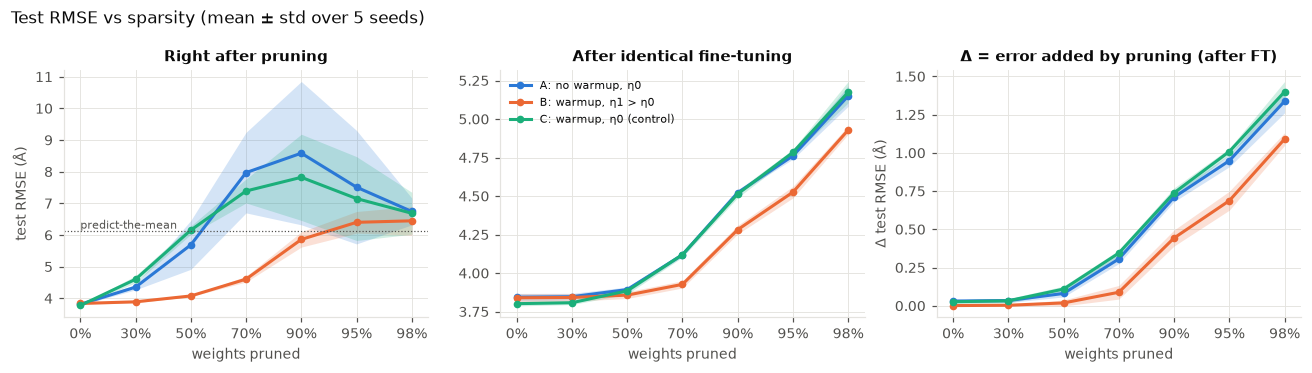

In [37]:
def sparsity_plot(results, metric, ax, names, colours, title):
    x = np.arange(len(SPARSITIES))
    for name in names:
        r = results[results["condition"] == name].groupby("sparsity")[metric]
        mean, std = r.mean().to_numpy(), r.std().to_numpy()
        ax.plot(x, mean, color=colours[name], marker="o", markersize=4, label=name)
        ax.fill_between(x, mean - std, mean + std, color=colours[name], alpha=0.2, linewidth=0)
    ax.set_xticks(x, [f"{s:.0%}" for s in SPARSITIES])
    ax.set_xlabel("weights pruned")
    ax.set_title(title)

colours = {A: BLUE, B: ORANGE, C: AQUA}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
sparsity_plot(pruning, "test_rmse_before_ft", axes[0], [A, B, C], colours, "Right after pruning")
sparsity_plot(pruning, "test_rmse_after_ft", axes[1], [A, B, C], colours, "After identical fine-tuning")
sparsity_plot(pruning, "delta", axes[2], [A, B, C], colours, "Δ = error added by pruning (after FT)")
axes[0].axhline(6.136, color=TEXT_SECONDARY, linewidth=0.8, linestyle=":")
axes[0].text(0, 6.2, "predict-the-mean", fontsize=7, color=TEXT_SECONDARY)
axes[0].set_ylabel("test RMSE (Å)")
axes[2].set_ylabel("Δ test RMSE (Å)")
axes[1].legend(loc="upper left", fontsize=7)
fig.suptitle("Test RMSE vs sparsity (mean ± std over 5 seeds)", x=0.01, ha="left")
fig.tight_layout()
plotting.save(fig, "pruning_vs_sparsity", "phase4")
plt.show()

In [38]:
for better, worse in [(B, A), (B, C), (C, A)]:
    print(f"\n{better}   vs   {worse}")
    print(paired_check(pruning, better, worse).round(3).to_string())


B: warmup, η1 > η0   vs   A: no warmup, η0
          mean_delta_diff  seed_std_of_diff seeds_better  counts
sparsity                                                        
0.70               -0.218             0.035          5/5    True
0.90               -0.267             0.050          5/5    True
0.95               -0.262             0.047          5/5    True
0.98               -0.247             0.104          5/5    True

B: warmup, η1 > η0   vs   C: warmup, η0 (control)
          mean_delta_diff  seed_std_of_diff seeds_better  counts
sparsity                                                        
0.70               -0.256             0.058          5/5    True
0.90               -0.295             0.037          5/5    True
0.95               -0.321             0.056          5/5    True
0.98               -0.309             0.071          5/5    True

C: warmup, η0 (control)   vs   A: no warmup, η0
          mean_delta_diff  seed_std_of_diff seeds_better  counts
sparsity   

In [39]:
# Were the unpruned networks comparable? And the dead-unit confounder (docs/03 §5)
pruning.groupby("condition")[["dense_val_rmse", "dense_test_rmse", "dead_fraction"]].agg(["mean", "std"]).round(3)

dense_val_rmse        dense_test_rmse         \
                                  mean    std            mean    std   
condition                                                              
A: no warmup, η0                 3.740  0.030           3.813  0.025   
B: warmup, η1 > η0               3.728  0.032           3.839  0.024   
C: warmup, η0 (control)          3.683  0.020           3.775  0.013   

                        dead_fraction         
                                 mean    std  
condition                                     
A: no warmup, η0                0.036  0.039  
B: warmup, η1 > η0              0.002  0.001  
C: warmup, η0 (control)         0.000  0.000

**H2: supported.** At comparable unpruned accuracy (validation 3.73 vs 3.74 Å; test 3.84 vs 3.81 Å,
so B starts slightly *worse*), the warmup network B loses **0.22–0.27 Å less** than A after pruning and
fine-tuning, at every sparsity ≥ 70 %, in **5/5 seeds**, ~5× the seed noise.
* *Right after pruning* (left panel) the difference is dramatic. At 70 % sparsity B's test RMSE is 4.6 Å,
  while A and C jump to 8.0 and 7.4 Å, worse than predicting the mean (6.14 Å). (A and C improve
  again at 98 % because a nearly empty network outputs almost a constant, i.e. close to the mean.)

**H3: supported. The benefit comes from the larger LR, not from warmup itself.** The control C (warmup
at A's small LR) is *not* more robust than A. It is if anything slightly less robust (+0.03 to +0.06 Å,
0–2/5 seeds better), even though C has the best unpruned RMSE (3.78 Å). B beats C by 0.26–0.32 Å in
5/5 seeds. So warmup helps pruning robustness **only through the larger LR it makes possible**.

**Confounders checked:**
* *Dead units* (could make pruning look "free"): A 3.6 %, B 0.2 %, C 0 %. B has the *fewest*, so this
  does not explain B's robustness.
* *The fine-tuning LR* (0.001) is 20 % of A's/C's training LR but only 0.5 % of B's. By Renda et al.,
  a relatively larger retraining LR should help A and C recover. B wins anyway.
* *Reference point:* measuring Δ against the *fine-tuned* dense network instead gives the same picture
  (B lower by 0.19–0.24 Å).

### 4.3 Post-hoc exploration: *why* is B more robust? (not pre-registered)

> This analysis was added **after** seeing the results, so it is exploration, not a hypothesis test.

Magnitude pruning assumes small weights are unimportant. If large-LR training concentrates the
network's "weight mass" in fewer, larger weights, then removing the many small ones costs less. Below:
the distribution of |w| for one trained network per condition (seed 0), and the share of the total
squared weight (Σw²) held by the largest 10 % and 30 % of weights. Pruning 70 % keeps exactly the
largest 30 %.

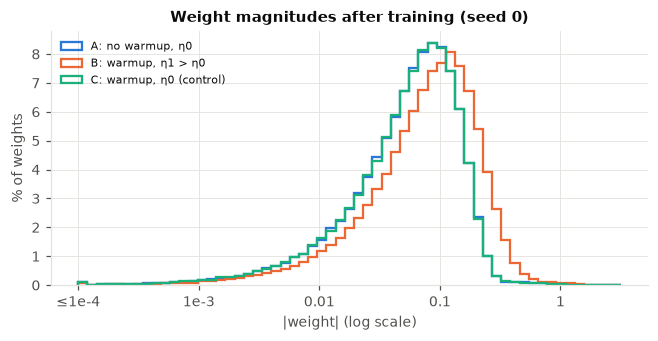

,median |w|,share of Σw² in top 10 %,share of Σw² in top 30 %
"A: no warmup, η0",0.062,0.565,0.833
"B: warmup, η1 > η0",0.084,0.606,0.856
"C: warmup, η0 (control)",0.062,0.564,0.833


In [40]:
def trained_weights(warmup, lr, seed=0):
    use_single_cpu_thread()
    model = train(schedule(warmup, lr, seed), wp_data.X_fit, wp_data.y_fit, wp_data.X_val, wp_data.y_val).model
    return torch.cat([layer.weight.detach().abs().flatten() for layer in model.linear_layers()]).numpy()

weights = {name: trained_weights(*spec) for name, spec in conditions.items()}

def top_share(w, fraction):
    w2 = np.sort(w ** 2)[::-1]
    return w2[: int(fraction * len(w2))].sum() / w2.sum()

fig, ax = plt.subplots(figsize=(7, 3))
bins = np.linspace(-4, 0.5, 60)   # log10 |w|. Weights below 1e-4 are lumped into the first bin
for name, w in weights.items():
    log_w = np.clip(np.log10(w + 1e-12), bins[0], bins[-1])
    ax.hist(log_w, bins=bins, histtype="step", linewidth=1.5, color=colours[name], label=name,
            weights=np.full(len(w), 100 / len(w)))
ax.set_xticks([-4, -3, -2, -1, 0], ["≤1e-4", "1e-3", "0.01", "0.1", "1"])
ax.set_xlabel("|weight| (log scale)")
ax.set_ylabel("% of weights")
ax.set_title("Weight magnitudes after training (seed 0)")
ax.legend(fontsize=7, loc="upper left")
plotting.save(fig, "weight_magnitudes", "phase4")
plt.show()

pd.DataFrame({name: {"median |w|": np.median(w), "share of Σw² in top 10 %": top_share(w, 0.10),
                     "share of Σw² in top 30 %": top_share(w, 0.30)} for name, w in weights.items()}).T.round(4)

**What the weights show (post-hoc, seed 0 only, so suggestive, not proof):** A and C have virtually
identical weight distributions (share of Σw² in the top 10 %: 56.5 % vs 56.4 %), matching their identical
pruning behaviour. B's weights are larger (median |w| 0.084 vs 0.062) and its weight mass is more
**concentrated** in its largest weights (top 10 %: 60.6 %; top 30 %: 85.6 % vs 83.3 %). A network that
relies more on a few large weights loses less when the many small ones are removed, which is exactly
the assumption magnitude pruning makes. A second explanation we did **not** test: large-LR training
ends in flatter (less sharp) minima, where zeroing weights changes the loss less.

### 4.4 Optional extensions (predictions pre-registered in `docs/03` §6)

* **E1: LR rewinding instead of fine-tuning** [Renda et al.]: retrain each pruned net for 10 epochs with
  its *own* schedule shape (same peak LR, warmup for the first 5 % if it had warmup, cosine to 0).
  *Prediction:* better recovery for all conditions, and a smaller A–B gap if the benefit comes from the LR
  used *after* pruning.
* **E2: warmup duration:** condition B with 1, 5 or 15 warmup epochs. *Prediction:* once warmup makes
  η₁ trainable, longer warmup adds no further robustness (a threshold effect).

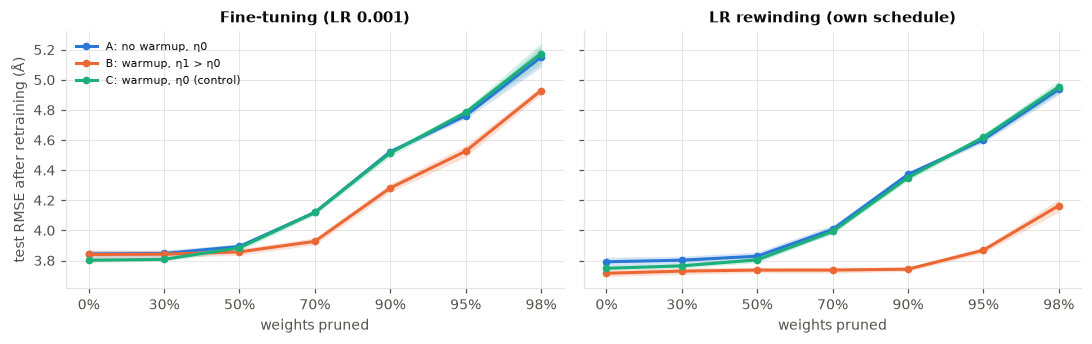

Retrained dense (0 %) test RMSE: {'A: no warmup, η0': 3.792, 'B: warmup, η1 > η0': 3.715, 'C: warmup, η0 (control)': 3.748}

Δ vs the retrained dense network (Å):
                 fine-tune                                                   LR rewind                                           
condition A: no warmup, η0 B: warmup, η1 > η0 C: warmup, η0 (control) A: no warmup, η0 B: warmup, η1 > η0 C: warmup, η0 (control)
sparsity                                                                                                                         
0.70                 0.275              0.087                   0.318            0.215              0.021                   0.245
0.90                 0.679              0.442                   0.712            0.580              0.027                   0.601
0.95                 0.918              0.686                   0.982            0.810              0.153                   0.871
0.98                 1.306              1.089            

In [41]:
rewind = prune_and_finetune(wp_data, conditions, retrain="lr_rewind", cache_name="phase4_ext_lr_rewind", rerun=RERUN)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
sparsity_plot(pruning, "test_rmse_after_ft", axes[0], [A, B, C], colours, "Fine-tuning (LR 0.001)")
sparsity_plot(rewind, "test_rmse_after_ft", axes[1], [A, B, C], colours, "LR rewinding (own schedule)")
axes[0].set_ylabel("test RMSE after retraining (Å)")
axes[0].legend(fontsize=7, loc="upper left")
fig.tight_layout()
plotting.save(fig, "ext_lr_rewinding", "phase4")
plt.show()

# LR rewinding also improves the UNPRUNED network (it is 10 more epochs at the network's own LR), so
# here Δ is measured against each seed's retrained dense (0 %) network, which isolates the cost of pruning.
def delta_vs_retrained_dense(results):
    ref = results[results["sparsity"] == 0].set_index(["condition", "seed"])["test_rmse_after_ft"]
    keys = pd.MultiIndex.from_frame(results[["condition", "seed"]])
    return results.assign(delta=results["test_rmse_after_ft"].to_numpy() - ref.reindex(keys).to_numpy())

print("Retrained dense (0 %) test RMSE:", rewind[rewind.sparsity == 0].groupby("condition")["test_rmse_after_ft"].mean().round(3).to_dict())
e1 = pd.concat({"fine-tune": delta_vs_retrained_dense(pruning).groupby(["sparsity", "condition"])["delta"].mean(),
                "LR rewind": delta_vs_retrained_dense(rewind).groupby(["sparsity", "condition"])["delta"].mean()},
               axis=1).unstack("condition")
print("\nΔ vs the retrained dense network (Å):")
print(e1.loc[[0.7, 0.9, 0.95, 0.98]].round(3).to_string())
print(f"\nLR rewinding: {B} vs {A}")
print(paired_check(delta_vs_retrained_dense(rewind), B, A).round(3).to_string())

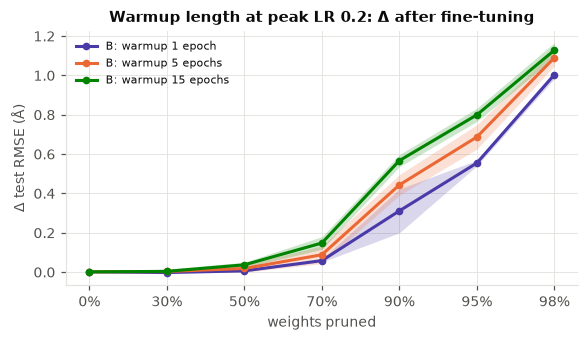

sparsity,dense test RMSE,0.7,0.9,0.95,0.98
condition,,,,,
B: warmup 1 epoch,3.872,0.059,0.312,0.555,1.004
B: warmup 15 epochs,3.791,0.148,0.567,0.800,1.129
B: warmup 5 epochs,3.839,0.088,0.443,0.687,1.090


In [42]:
eta1 = conditions[B][1]
durations = {f"B: warmup {w} epoch{'s' if w > 1 else ''}": (True, eta1, w) for w in [1, 5, 15]}
duration = prune_and_finetune(wp_data, durations, cache_name="phase4_ext_warmup_duration", rerun=RERUN)

dur_colours = dict(zip(durations, [VIOLET, ORANGE, GREEN]))
fig, ax = plt.subplots(figsize=(6, 3))
sparsity_plot(duration, "delta", ax, list(durations), dur_colours, f"Warmup length at peak LR {eta1:g}: Δ after fine-tuning")
ax.set_ylabel("Δ test RMSE (Å)")
ax.legend(fontsize=7)
plotting.save(fig, "ext_warmup_duration", "phase4")
plt.show()

d = duration.groupby(["condition", "sparsity"])["delta"].mean().unstack("sparsity")[[0.7, 0.9, 0.95, 0.98]]
d.insert(0, "dense test RMSE", duration.groupby("condition")["dense_test_rmse"].mean())
d.round(3)

**E1 (LR rewinding): recovery improves for everyone, but the A–B gap widens. Prediction contradicted.**
Measured against each network's own retrained dense version, LR rewinding cuts B's pruning cost to almost
nothing up to 90 % sparsity (+0.02, +0.03 Å), while A still loses 0.22 and 0.58 Å. We predicted a
*smaller* gap. With rewinding, each condition retrains at its *own* peak LR: B at 0.2, A at 0.005. This
reproduces Renda et al.'s finding that a large retraining LR recovers better. So the large LR that
warmup enables helps **twice**: the trained network is more robust, *and* it can be retrained at a
large LR. (Also: rewinding improves even the unpruned B network, 3.84 → 3.72 Å, a sign that B was not
fully converged after 100 epochs.)

**E2 (warmup length at LR 0.2): partly supported, with a twist.**
* **Even 1 epoch** of warmup makes LR 0.2 trainable.
* 1 vs 5 epochs: no consistent difference in robustness (1–2/5 seeds), as the threshold prediction said.
* But **15 epochs is *less* robust than 5** (4–5/5 seeds, by 0.04–0.12 Å), while having the *best*
  unpruned RMSE (3.79 vs 3.84 Å). A longer warmup means fewer epochs at the large LR, so this fits the
  "robustness comes from training at a large LR" picture. It is an untested explanation.

### 4.5 Conclusion (spec step 4)

**Did we observe the effect? Yes, clearly.** With unpruned accuracy matched (validation 3.73 vs 3.74 Å),
the warmup-trained network lost 0.22–0.27 Å less accuracy after pruning and fine-tuning (≥ 70 % sparsity,
5/5 seeds), and far less before fine-tuning.

**Do the results support the proposed mechanism (warmup → larger tolerable LR → better pruning
robustness)? Yes, on both links:**
1. *Warmup → larger LR:* without warmup the network diverges in epoch 1 above LR 0.005. With warmup it
   trains at 0.2 (H1, ≥ 20×).
2. *Larger LR → robustness:* warmup *without* a larger LR (C) gives no robustness benefit (H3). Only the
   large-LR network (B) is robust. E1 adds that the large LR also helps the *recovery* phase.

So warmup's effect on pruning robustness is **indirect**, as the hypothesis claims: in our setting
warmup matters *because* it unlocks a large learning rate.

**Limitations:** one dataset and one architecture (a tabular MLP, unlike the CNNs of the original
papers); one-shot rather than iterative pruning; a single fit/validation split; and B's LR (0.2) was
set by our "comparable accuracy" rule at the edge of the grid. The mechanism *behind* the large-LR
robustness (weight concentration, flatter minima) is only explored post-hoc, not tested.